# Exploratory Data Analysis (EDA)
---
## Tasks done in this notebook:
- Data Loading and First look 
- Data Quality Visualization 
- Target Variable Distribution 
- Univariate Analysis for Numerical features 
- Univariate Analysis for Categorical features
- Bivariate Analysis for Numerical features vs Target feature 
- Bivariate Analysis for Categorical features vs Target feature
- Correlation Matrix for Numerical features
- Time Based patterns to track transaction throughout the full day 
- Amount Analysis deep dive
- Velocity and Behavior Signals
- Device Trust and Location Signals
- Demographic Insight using the cardholder age
- Interaction Exploration 
- EDA Summary and Hypotheses

In [1]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D
from pandas.plotting import parallel_coordinates

### Data Loading and First Look

In [2]:
credit_data_df = pd.read_csv('../data/interim/cleaned/credit_card_fraud_10k_cleaned.csv')
credit_data_df.columns = credit_data_df.columns.str.strip()

print("ORIGINAL DATASET")
print(f"Shape: {credit_data_df.shape}")
display(credit_data_df.head())
credit_data_df.info()


smote_data_df = pd.read_csv('../data/interim/smote/X_train_smote_eda.csv')
smote_data_df.columns = smote_data_df.columns.str.strip()

print("\nSMOTE DATASET")
print(f"Shape: {smote_data_df.shape}")
display(smote_data_df.head())
smote_data_df.info()


continuous_cols = ['amount', 'transaction_hour', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']
categorical_analysis_cols = ['merchant_category', 'foreign_transaction', 'location_mismatch']


merchant_dummy_cols = [col for col in smote_data_df.columns if 'merchant_category_' in col]

if merchant_dummy_cols:
    def reverse_one_hot(row):
        for col in merchant_dummy_cols:
            if row[col] == 1:
                return col.replace('merchant_category_', '').strip()
        return 'Clothing'
    
    smote_data_df['merchant_category'] = smote_data_df.apply(reverse_one_hot, axis=1)
    print("\nSuccessfully reconstructed 'merchant_category' in smote_data_df.")

credit_data_df['is_fraud'] = credit_data_df['is_fraud'].astype(int)
smote_data_df['is_fraud'] = smote_data_df['is_fraud'].astype(int)
fraud_colors = ['lightblue', 'salmon']

ORIGINAL DATASET
Shape: (10000, 10)


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66.0,3.0,40,0
1,2,541.82,3,Travel,1,0,87.0,1.0,64,0
2,3,237.01,17,Grocery,0,0,49.0,1.0,61,0
3,4,164.33,4,Grocery,0,1,72.0,3.0,34,0
4,5,30.53,15,Food,0,0,79.0,0.0,44,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  float64
 7   velocity_last_24h    10000 non-null  float64
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 781.4+ KB

SMOTE DATASET
Shape: (13786, 13)


,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_ Electronics,merchant_category_ Food,merchant_category_ Grocery,merchant_category_ Travel,is_fraud
0,4344,315.12,17,0,0,78.0,1.0,46,False,True,False,False,0
1,2144,67.93,6,0,0,45.0,1.0,67,True,False,False,False,0
2,9845,22.07,13,0,0,33.0,4.0,44,False,False,False,False,0
3,2349,162.10,6,0,0,78.0,4.0,38,False,True,False,False,0
4,2091,268.99,1,0,0,63.0,4.0,67,True,False,False,False,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13786 entries, 0 to 13785
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  13786 non-null  int64  
 1   amount                          13786 non-null  float64
 2   transaction_hour                13786 non-null  int64  
 3   foreign_transaction             13786 non-null  int64  
 4   location_mismatch               13786 non-null  int64  
 5   device_trust_score              13786 non-null  float64
 6   velocity_last_24h               13786 non-null  float64
 7   cardholder_age                  13786 non-null  int64  
 8   merchant_category_ Electronics  13786 non-null  bool   
 9   merchant_category_ Food         13786 non-null  bool   
 10  merchant_category_ Grocery      13786 non-null  bool   
 11  merchant_category_ Travel       13786 non-null  bool   
 12  is_fraud                        

### Data Quality Visualization

Data Quality Visualizations:


C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\2762360600.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2, 0].boxplot(


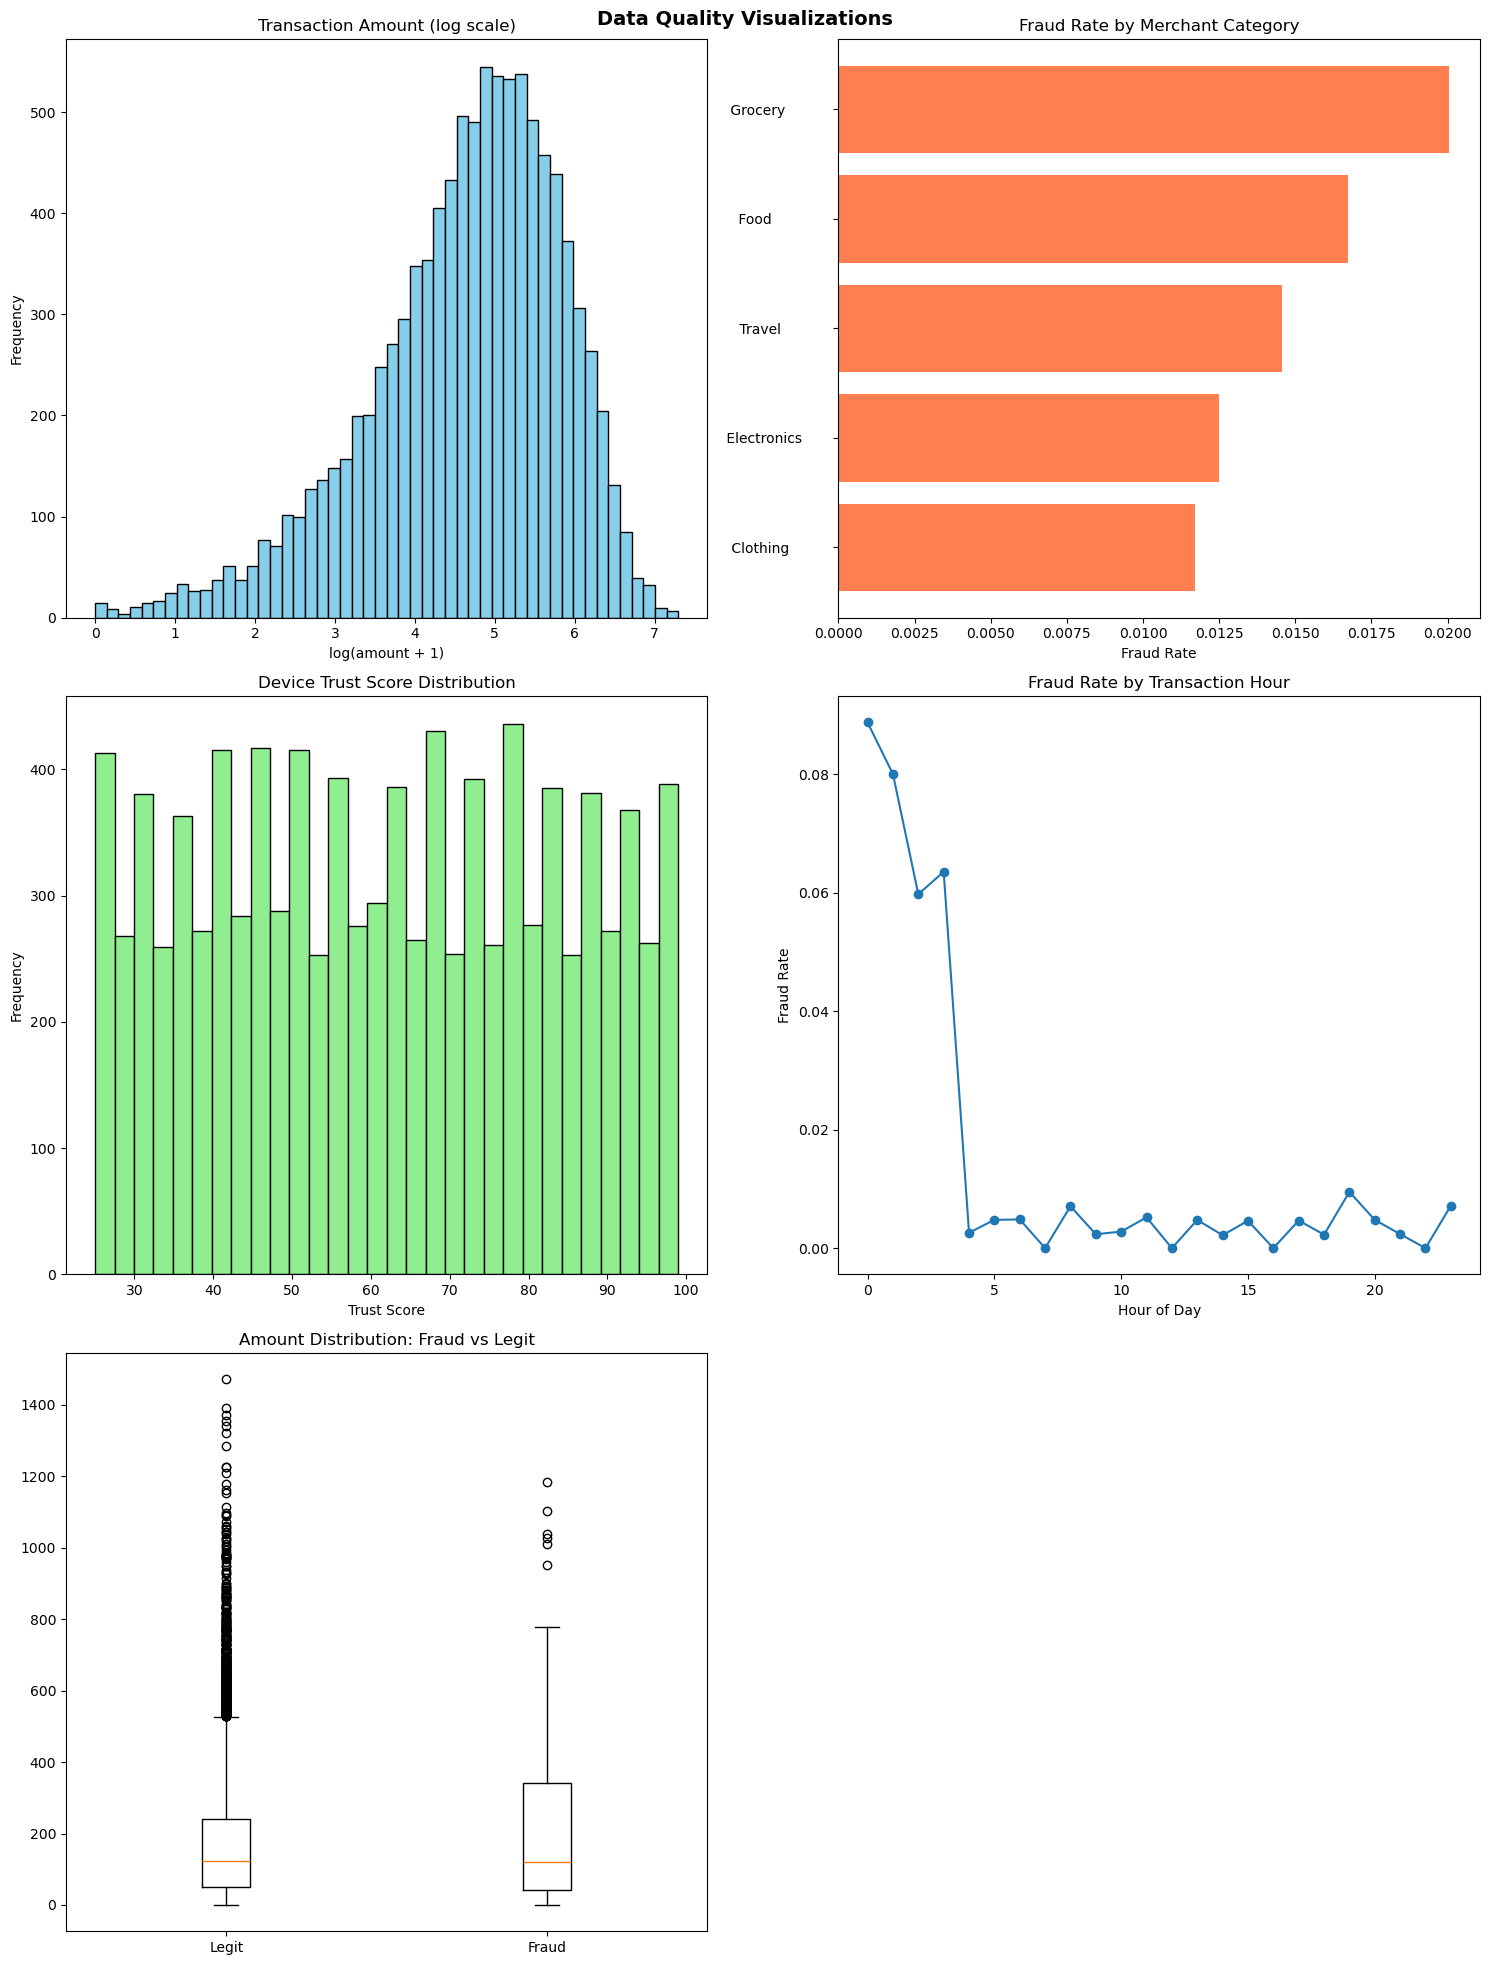

In [3]:
print("Data Quality Visualizations:")
fig, axes = plt.subplots(3, 2, figsize=(15, 20))
fig.suptitle('Data Quality Visualizations', fontsize=14, fontweight='bold')

axes[0, 0].hist(
    np.log1p(credit_data_df['amount']), 
    bins=50, 
    edgecolor='black', 
    color='skyblue'
    )
axes[0, 0].set_title('Transaction Amount (log scale)')
axes[0, 0].set_xlabel('log(amount + 1)')
axes[0, 0].set_ylabel('Frequency')

fraud_by_category = credit_data_df.groupby('merchant_category')['is_fraud'].mean().sort_values()
axes[0, 1].barh(
    fraud_by_category.index, 
    fraud_by_category.values, 
    color='coral'
    )
axes[0, 1].set_title('Fraud Rate by Merchant Category')
axes[0, 1].set_xlabel('Fraud Rate')

axes[1, 0].hist(
    credit_data_df['device_trust_score'],
    bins=30, 
    edgecolor='black', 
    color='lightgreen'
    )
axes[1, 0].set_title('Device Trust Score Distribution')
axes[1, 0].set_xlabel('Trust Score')
axes[1, 0].set_ylabel('Frequency')

hourly_fraud = credit_data_df.groupby('transaction_hour')['is_fraud'].mean()
axes[1, 1].plot(
    hourly_fraud.index, 
    hourly_fraud.values, 
    marker='o'
    )
axes[1, 1].set_title('Fraud Rate by Transaction Hour')
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Fraud Rate')

axes[2, 0].boxplot(
    [credit_data_df[credit_data_df['is_fraud']==0]['amount'], 
    credit_data_df[credit_data_df['is_fraud']==1]['amount']], 
    labels=['Legit', 'Fraud']
    )
axes[2, 0].set_title('Amount Distribution: Fraud vs Legit')

axes[2, 1].axis('off')  
plt.tight_layout()
plt.show()

### Target Variable Distribution


Fraud vs Legitimate Transaction Counts:
is_fraud
0    9849
1     151
Name: count, dtype: int64

Percentage of Fraudulent Transactions: 1.51%
Percentage of Legitimate Transactions: 98.49%


C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\535049719.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


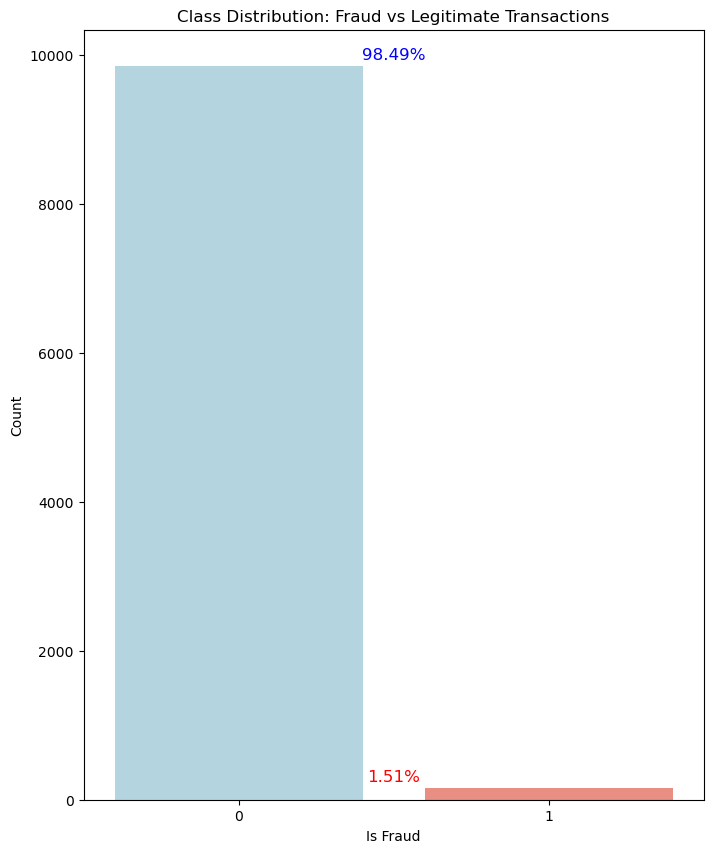

In [4]:
fraud_counts = credit_data_df['is_fraud'].value_counts()
print("\nFraud vs Legitimate Transaction Counts:")
print(fraud_counts)
fraud_percentage = credit_data_df['is_fraud'].mean() * 100
print(f"\nPercentage of Fraudulent Transactions: {fraud_percentage:.2f}%")  
legit_percentage = 100 - fraud_percentage
print(f"Percentage of Legitimate Transactions: {legit_percentage:.2f}%")

plt.figure(figsize=(8, 10))
sns.countplot(
    x='is_fraud', 
    data=credit_data_df, 
    palette=['lightblue', 'salmon']
    )
plt.title('Class Distribution: Fraud vs Legitimate Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.text(
    0.5, 
    fraud_counts[1] + 50, 
    f'{fraud_percentage:.2f}%', 
    ha='center', 
    va='bottom', 
    fontsize=12, 
    color='red'
    )
plt.text(
    0.5, 
    fraud_counts[0] + 50, 
    f'{legit_percentage:.2f}%', 
    ha='center', 
    va='bottom', 
    fontsize=12, 
    color='blue'
    )
plt.show()


### Univariate Analysis – Numerical Features


Histograms: Original vs SMOTE


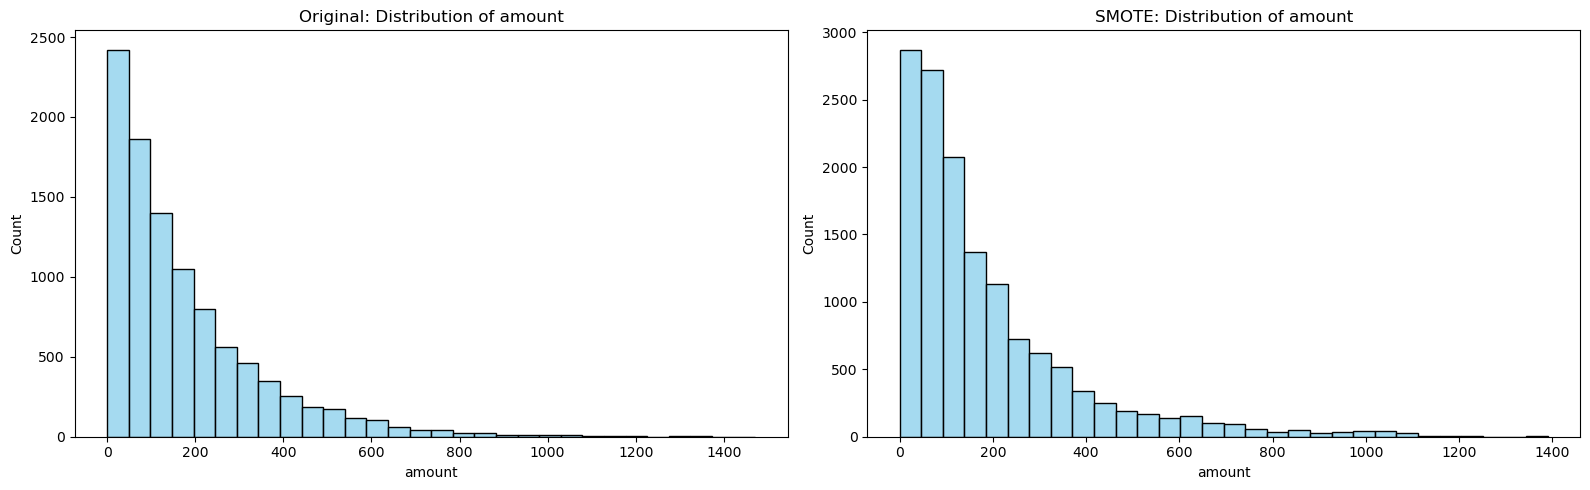

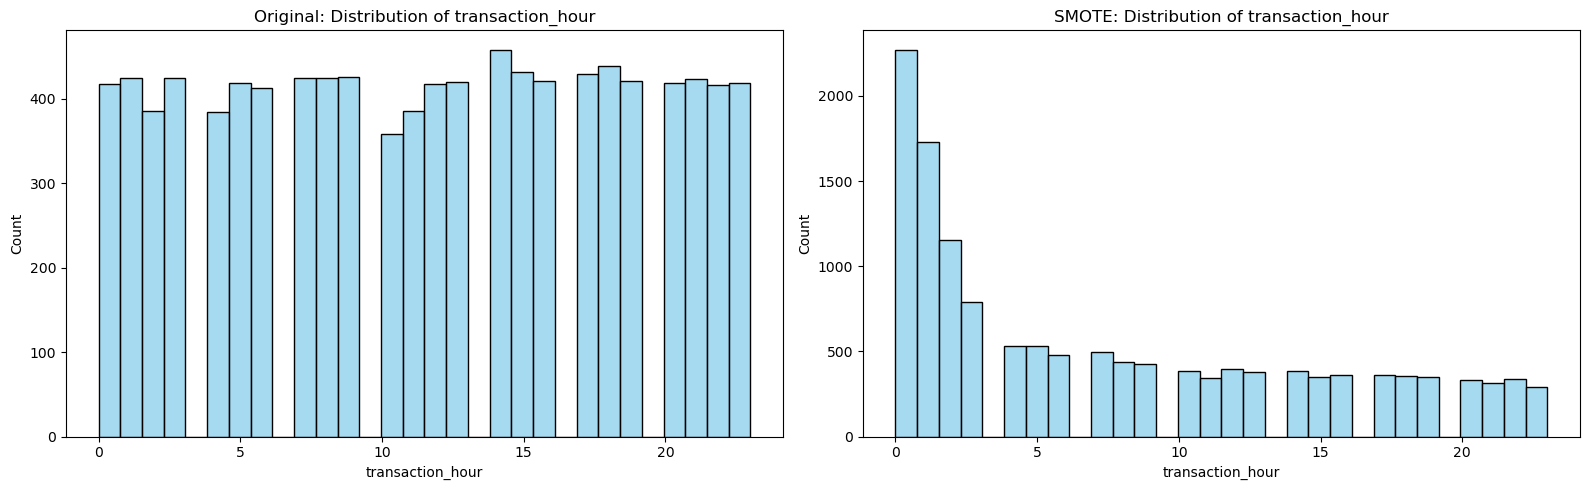

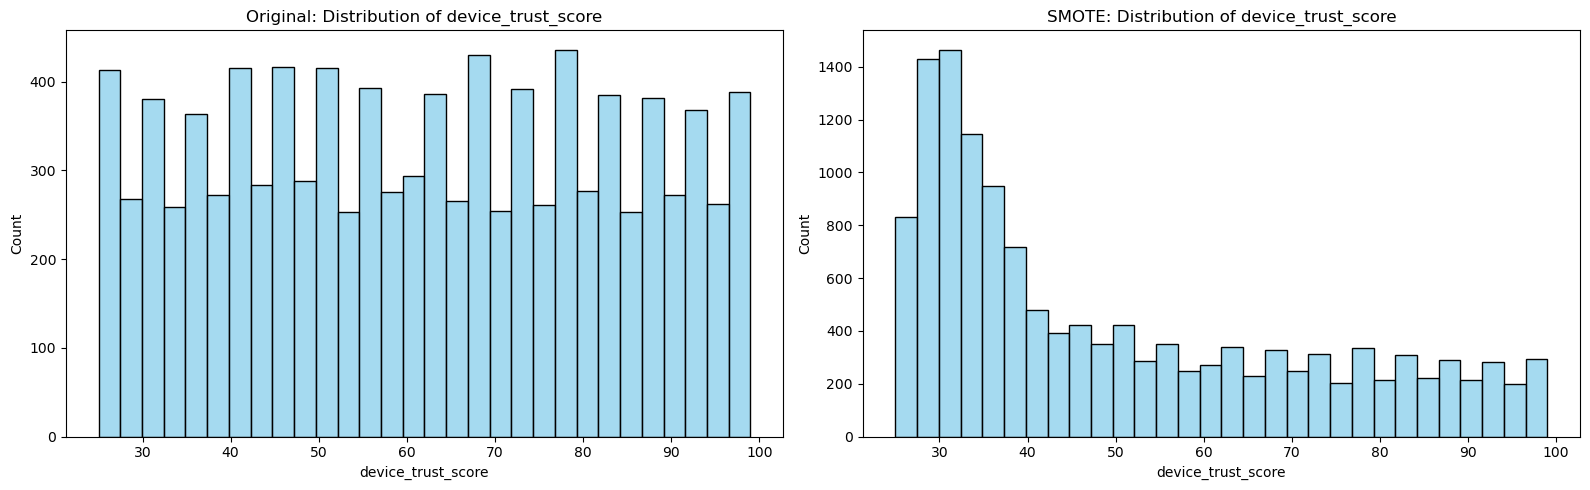

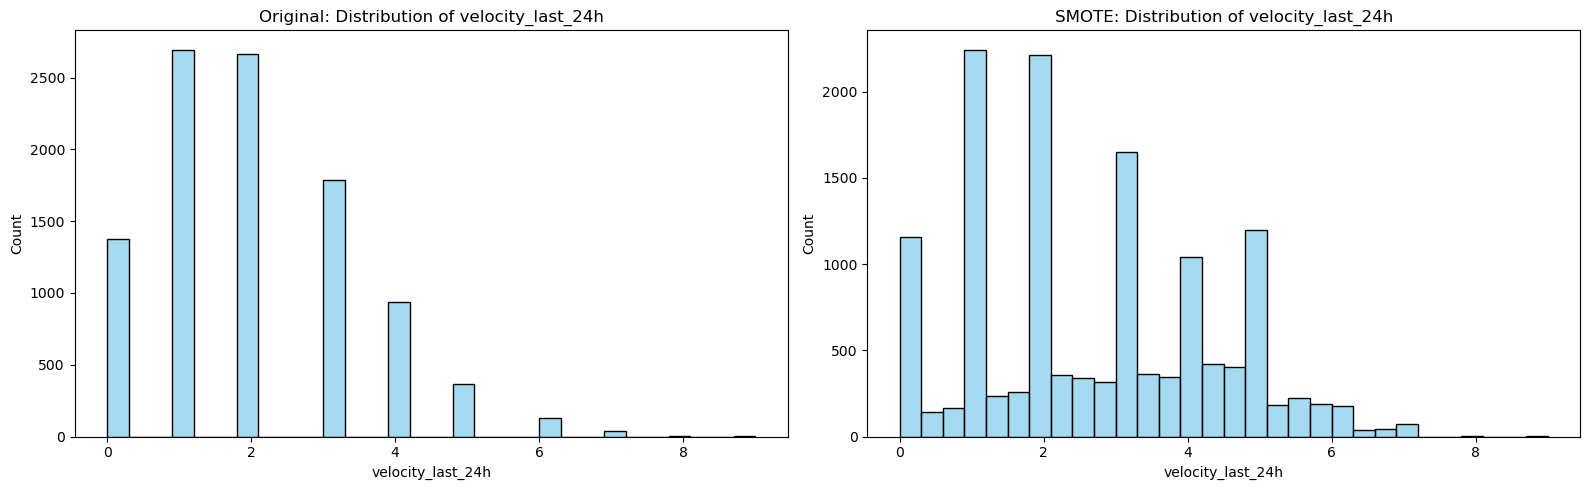

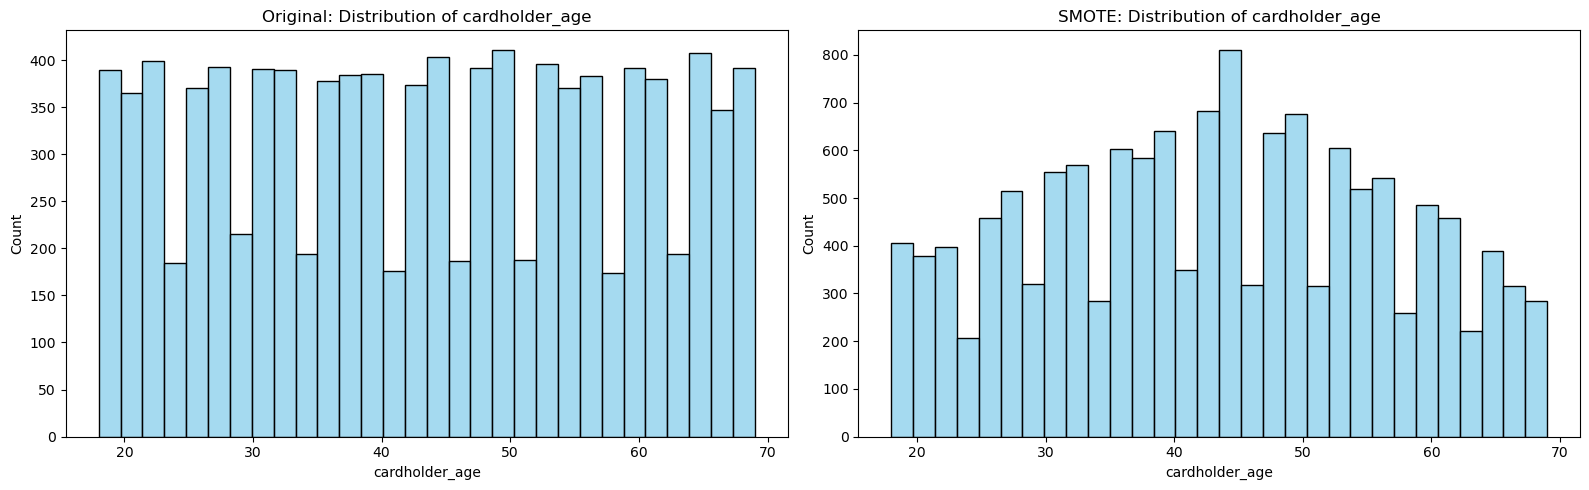


KDE Plots: Original vs SMOTE (by Fraud Status)


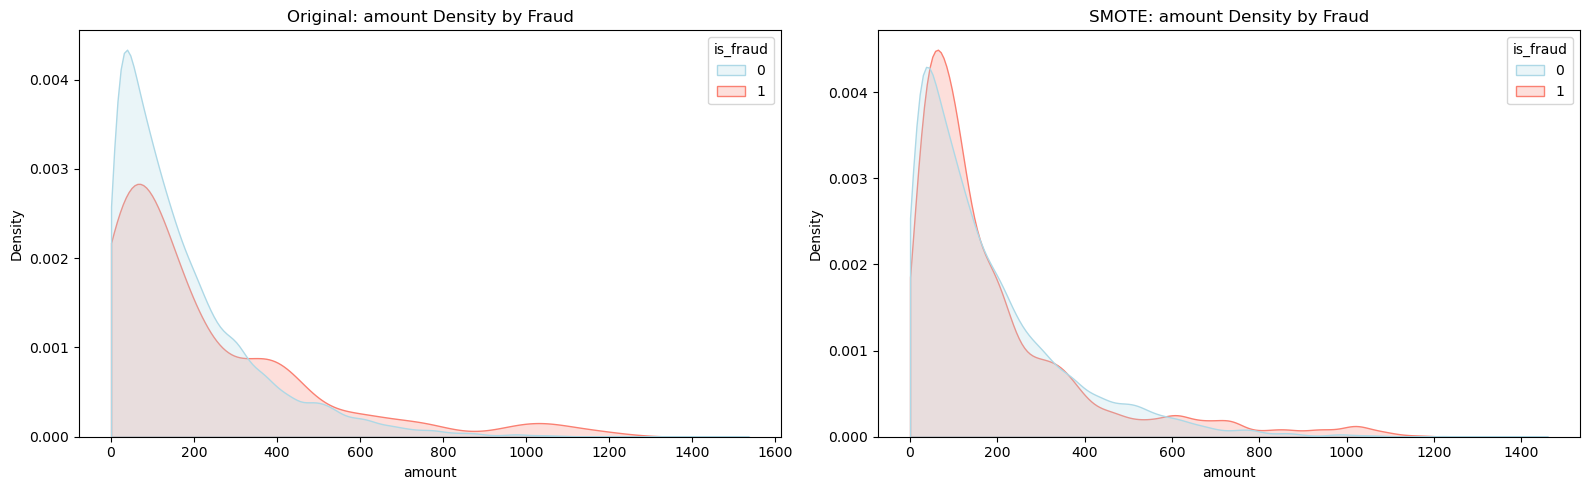

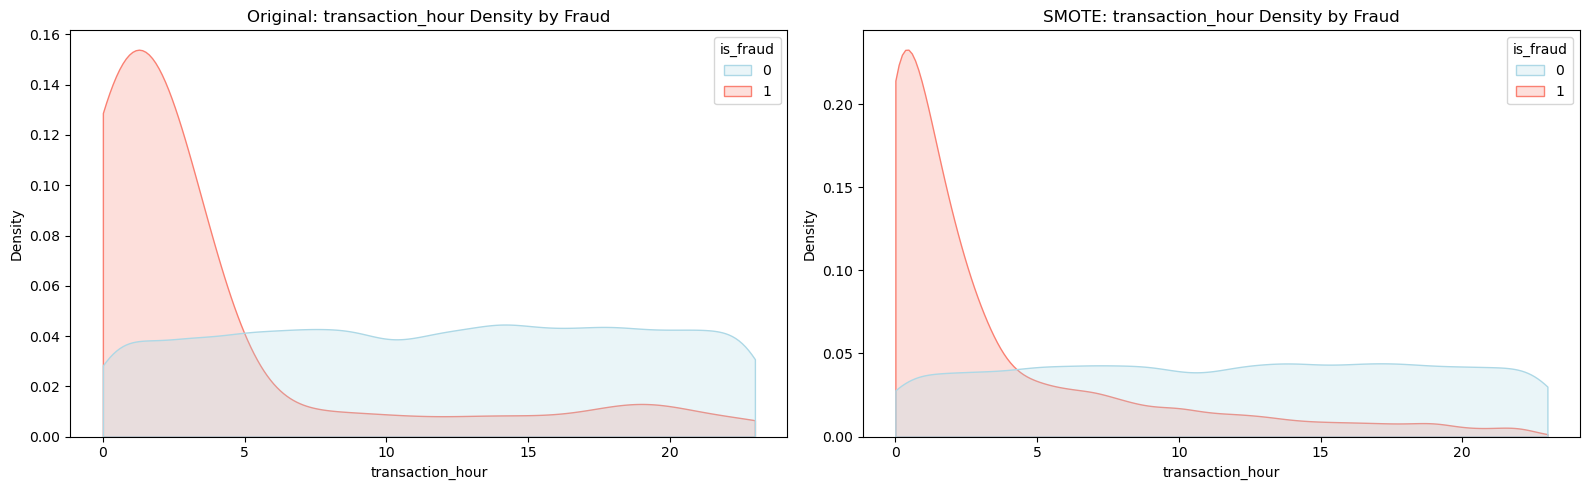

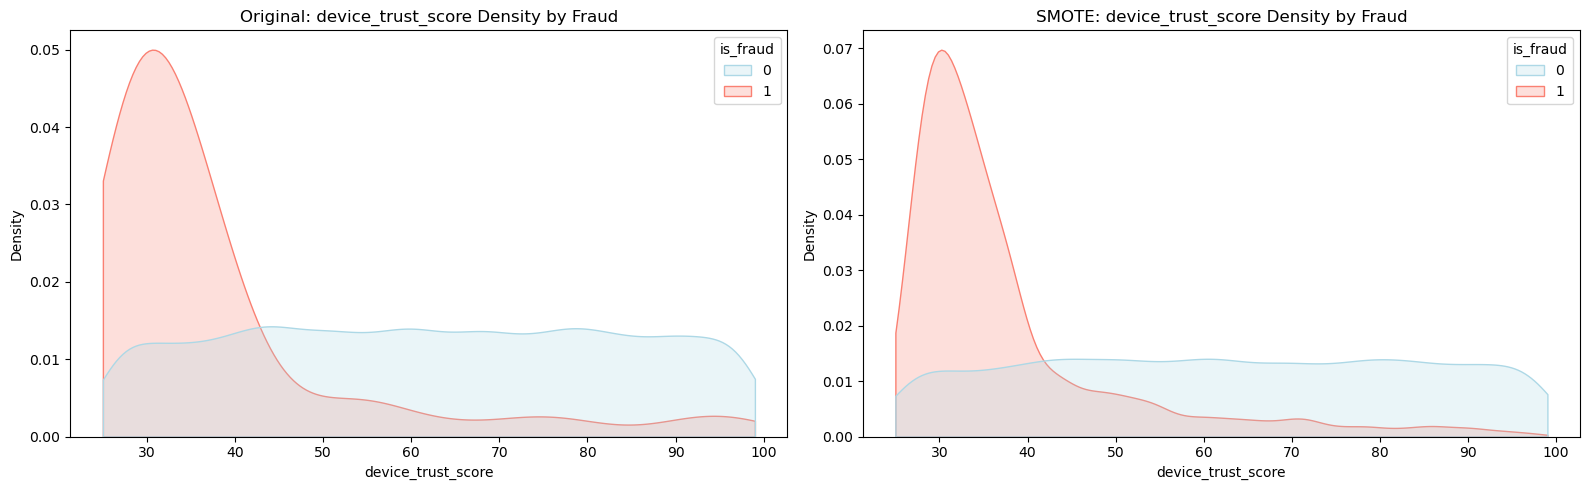

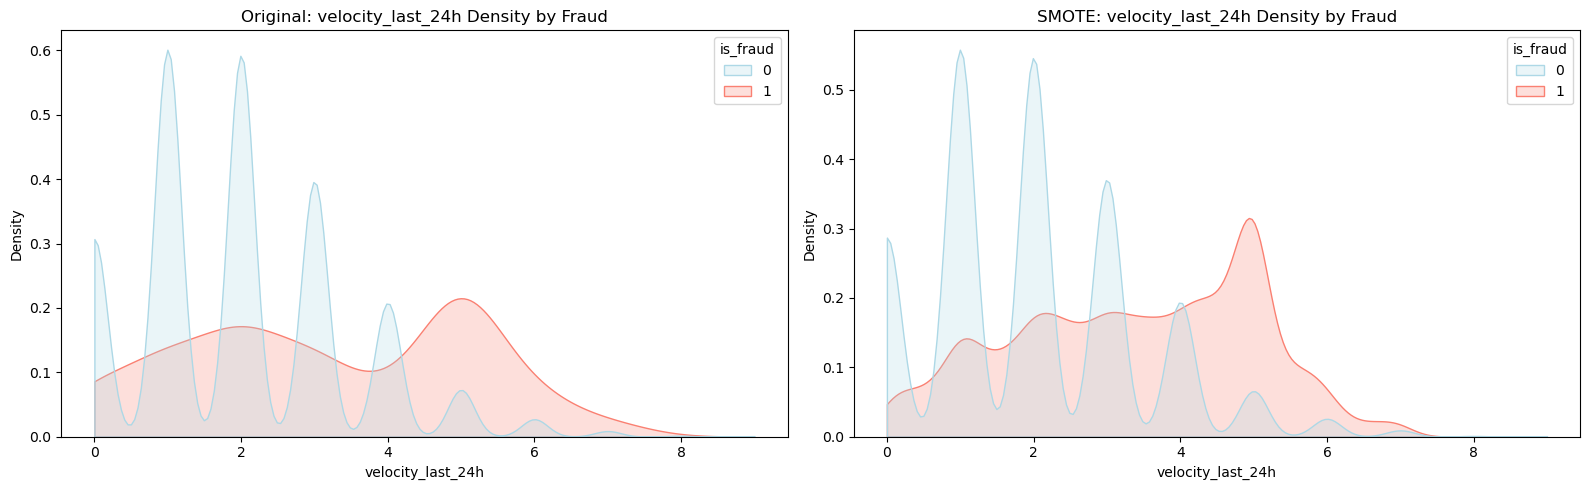

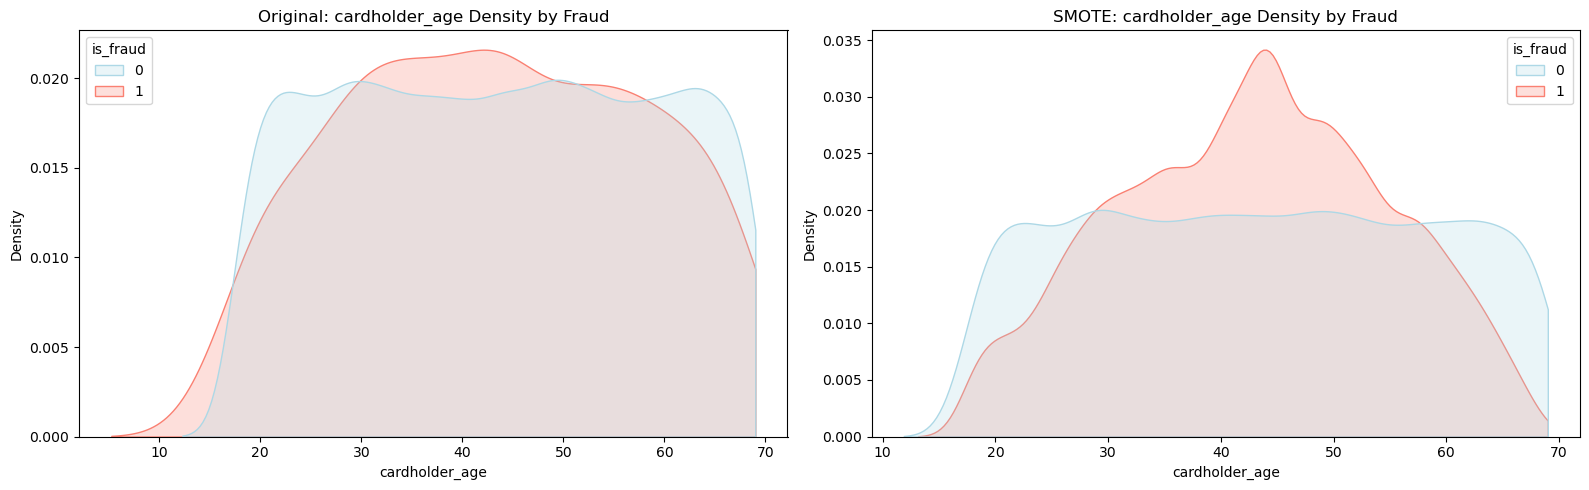


Box Plots: Original vs SMOTE


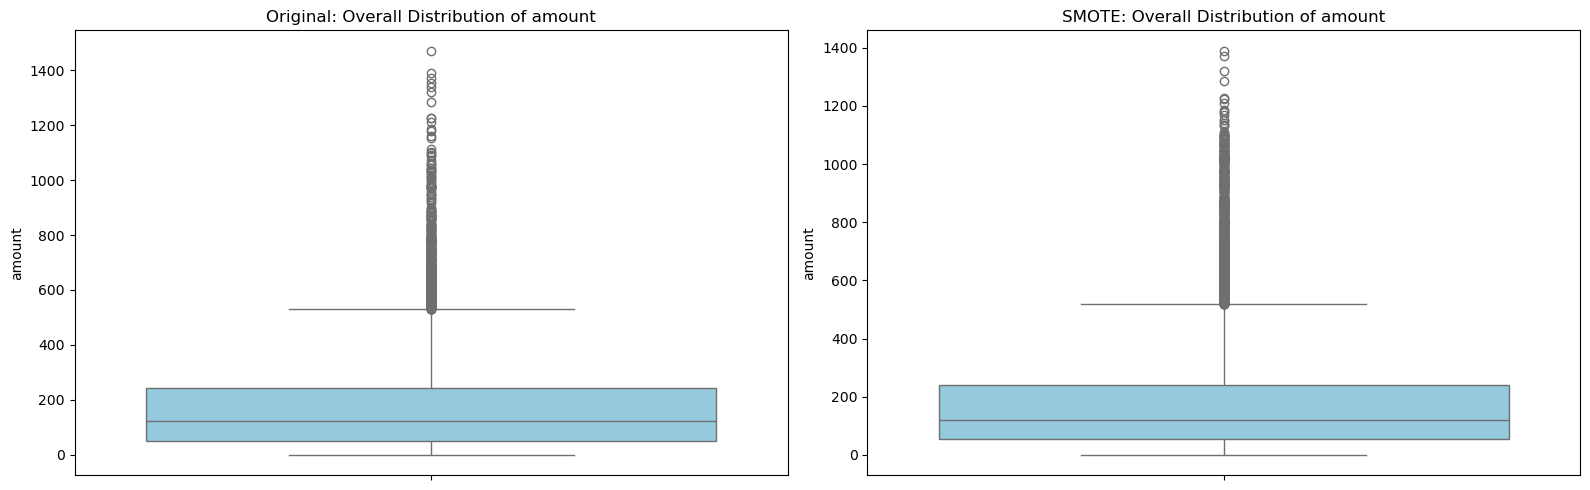

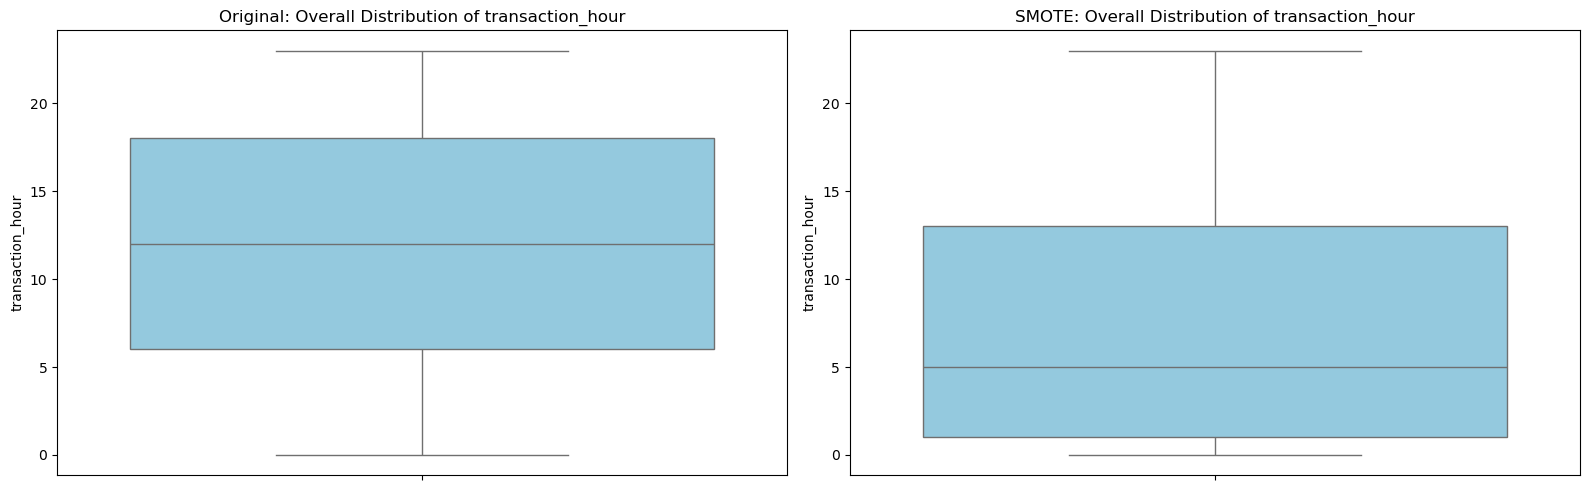

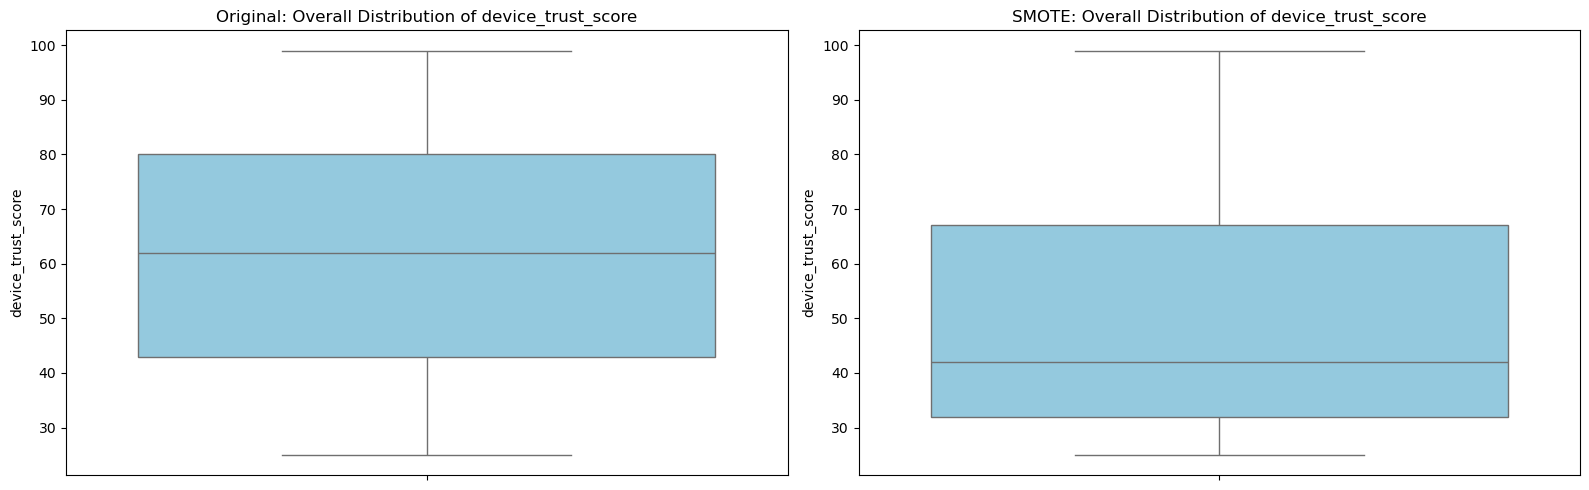

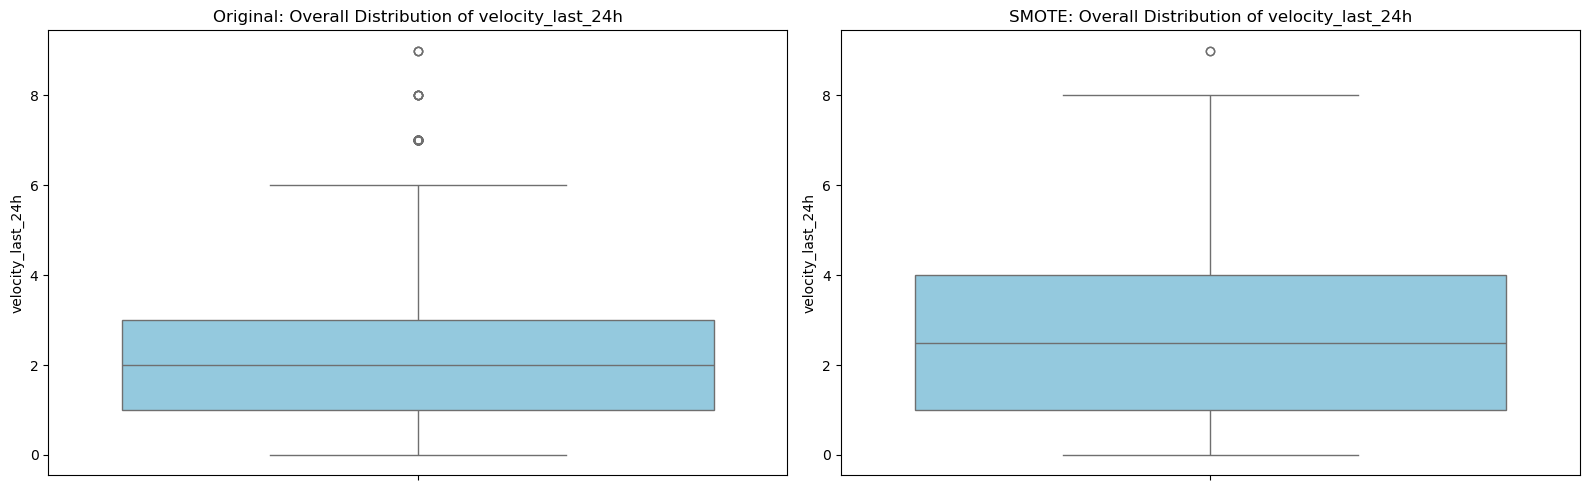

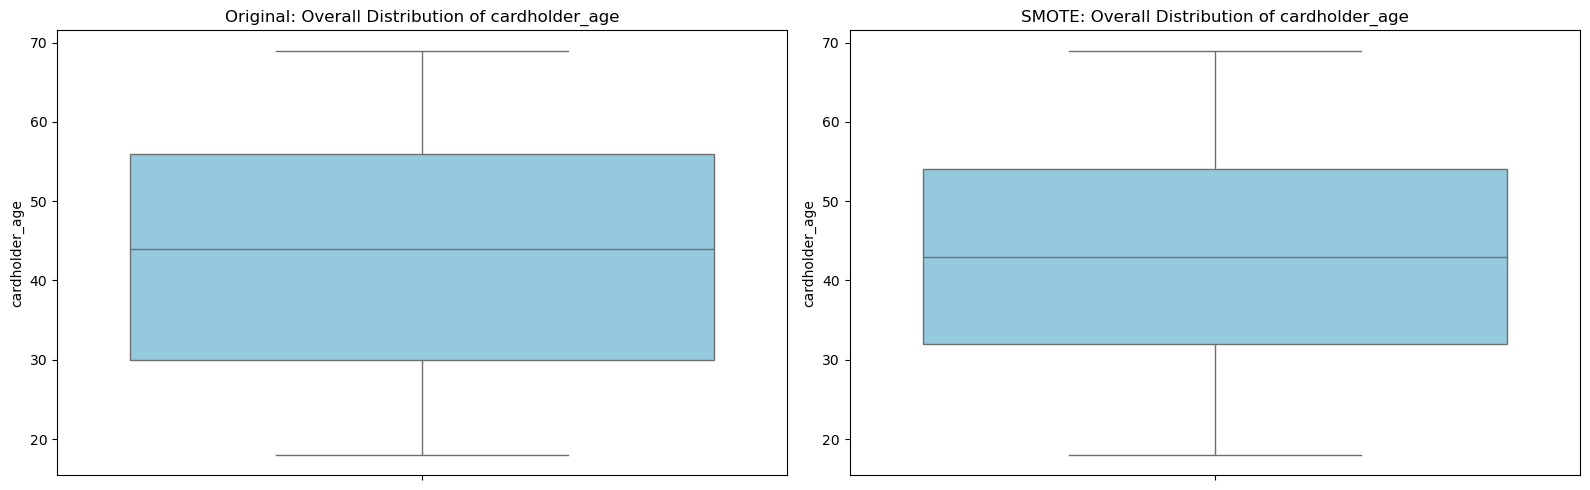


Violin Plots: Original vs SMOTE (by Fraud Status)


C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\4252237236.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=credit_data_df,
C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\4252237236.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=smote_data_df,


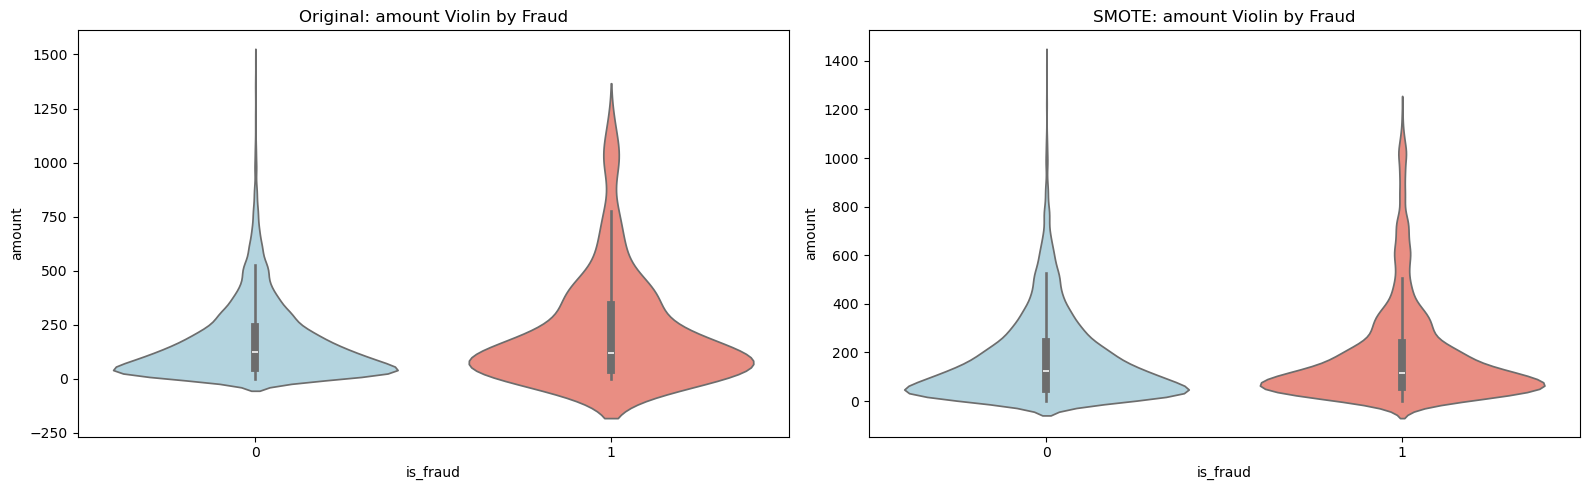

C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\4252237236.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=credit_data_df,
C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\4252237236.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=smote_data_df,


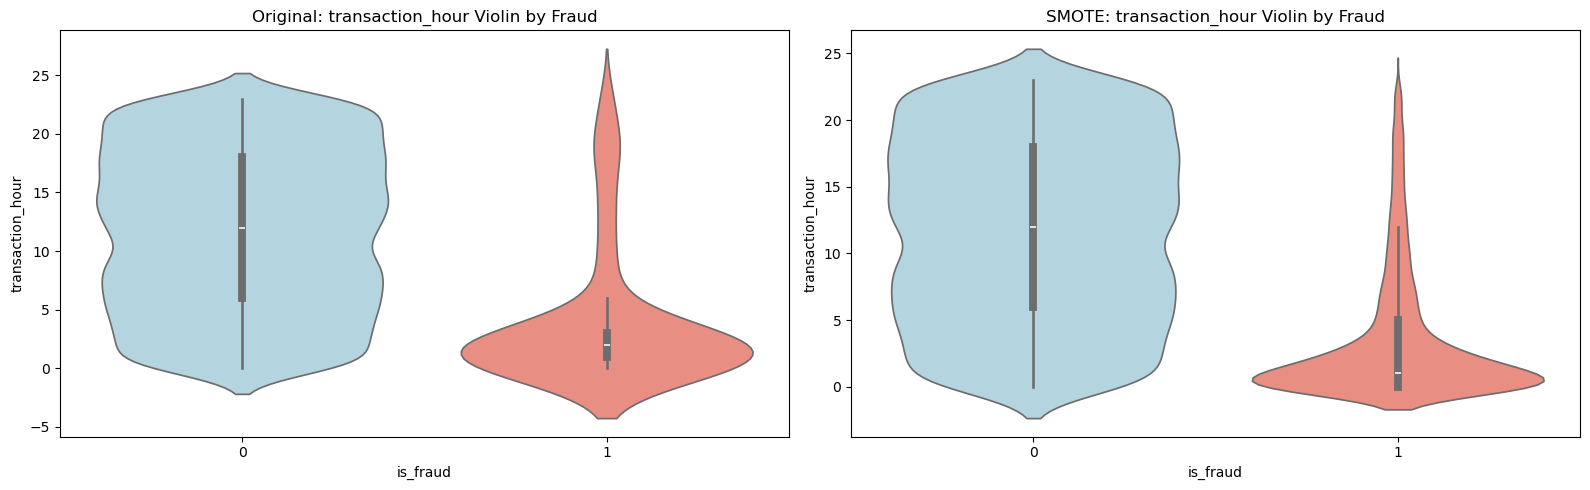

C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\4252237236.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=credit_data_df,
C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\4252237236.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=smote_data_df,


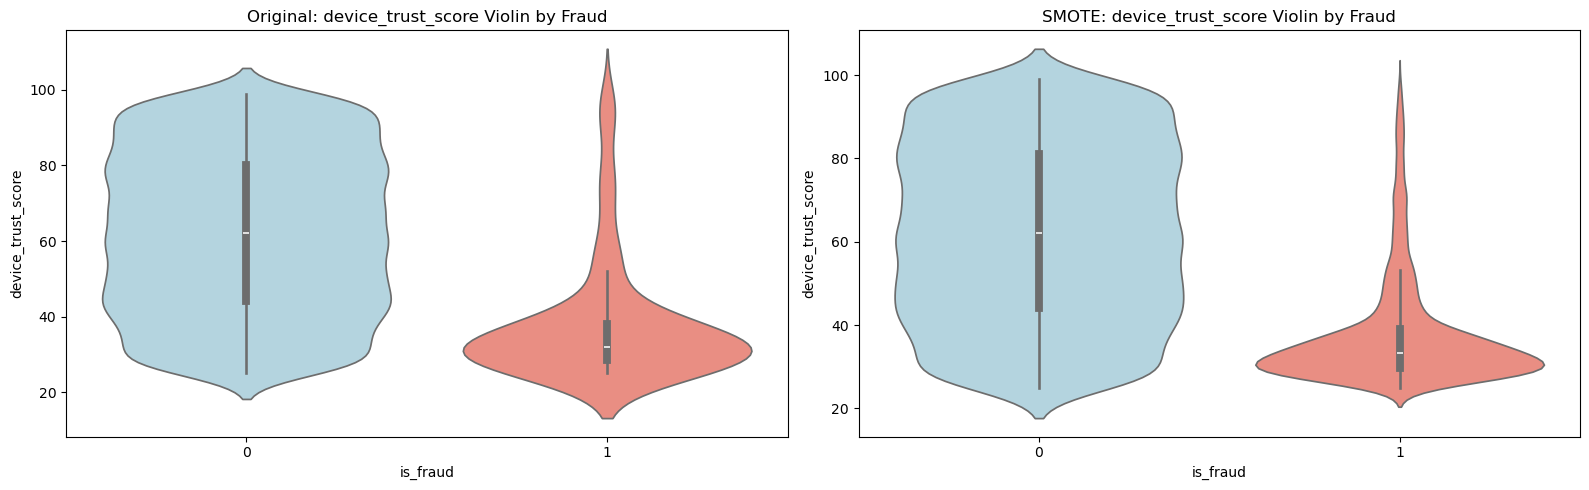

C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\4252237236.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=credit_data_df,
C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\4252237236.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=smote_data_df,


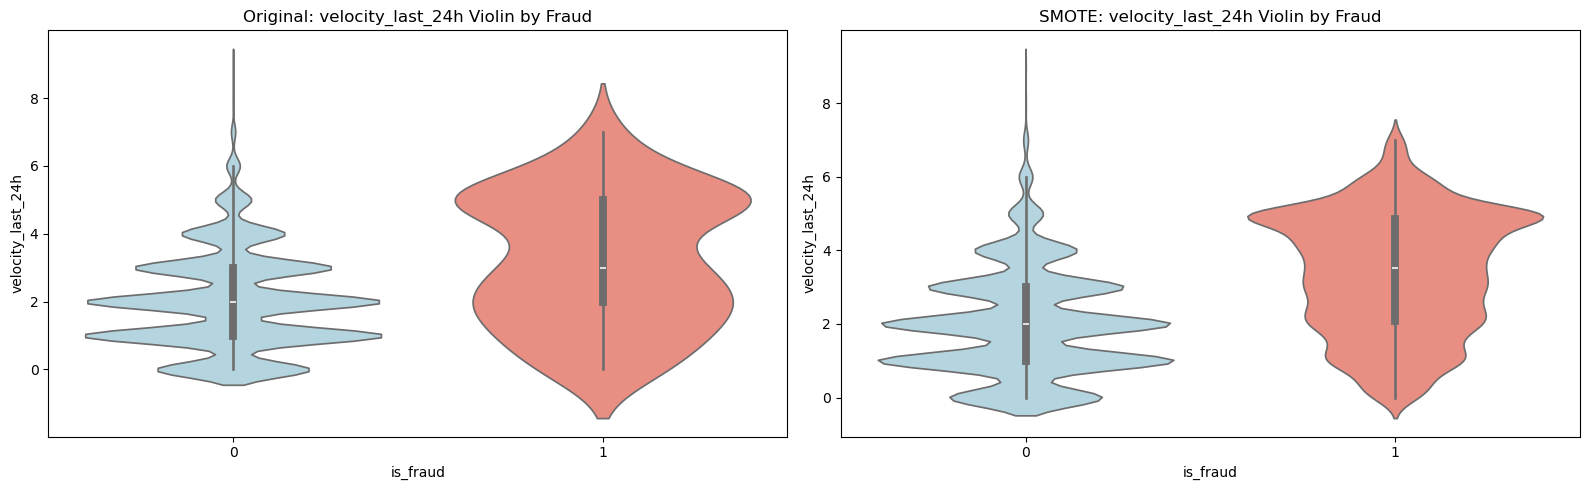

C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\4252237236.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=credit_data_df,
C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\4252237236.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=smote_data_df,


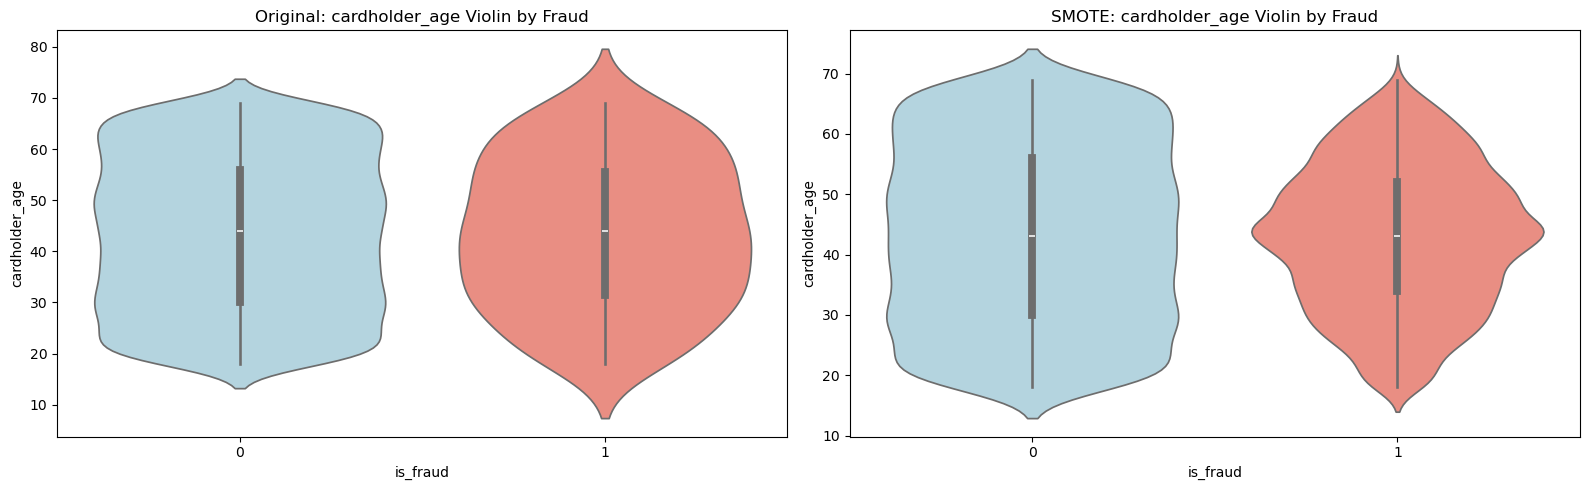

In [5]:
print("\nHistograms: Original vs SMOTE")
for col in continuous_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.histplot(credit_data_df[col], bins=30, color='skyblue', ax=axes[0])
    axes[0].set_title(f'Original: Distribution of {col}')

    sns.histplot(smote_data_df[col], bins=30, color='skyblue', ax=axes[1])
    axes[1].set_title(f'SMOTE: Distribution of {col}')
    
    plt.tight_layout()
    plt.show()

print("\nKDE Plots: Original vs SMOTE (by Fraud Status)")

feature_bounds = {
    "amount": (0, None),
    "transaction_hour": (0, 23),
    "device_trust_score": (25, 99),
    "velocity_last_24h": (0, 9),
    "cardholder_age": (0, 69)
}

for col in continuous_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    lower, upper = feature_bounds.get(col, (None, None))

    sns.kdeplot(
        data=credit_data_df,
        x=col,
        hue='is_fraud',
        fill=True,
        common_norm=False,
        palette=fraud_colors,
        clip=(lower, upper),
        bw_adjust=0.8,
        ax=axes[0]
    )
    axes[0].set_title(f'Original: {col} Density by Fraud')

    sns.kdeplot(
        data=smote_data_df,
        x=col,
        hue='is_fraud',
        fill=True,
        common_norm=False,
        palette=fraud_colors,
        clip=(lower, upper),
        bw_adjust=0.8,
        ax=axes[1]
    )
    axes[1].set_title(f'SMOTE: {col} Density by Fraud')

    plt.tight_layout()
    plt.show()

print("\nBox Plots: Original vs SMOTE")
for col in continuous_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.boxplot(y=credit_data_df[col], color='skyblue', ax=axes[0])
    axes[0].set_title(f'Original: Overall Distribution of {col}')
    
    sns.boxplot(y=smote_data_df[col], color='skyblue', ax=axes[1])
    axes[1].set_title(f'SMOTE: Overall Distribution of {col}')
    
    plt.tight_layout()
    plt.show()

print("\nViolin Plots: Original vs SMOTE (by Fraud Status)")
for col in continuous_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.violinplot(x='is_fraud', y=col, data=credit_data_df, 
                   palette=fraud_colors, ax=axes[0])
    axes[0].set_title(f'Original: {col} Violin by Fraud')
    
    sns.violinplot(x='is_fraud', y=col, data=smote_data_df, 
                   palette=fraud_colors, ax=axes[1])
    axes[1].set_title(f'SMOTE: {col} Violin by Fraud')
    
    plt.tight_layout()
    plt.show()

### Univariate Analysis – Categorical Features


Bar Charts: Original vs SMOTE


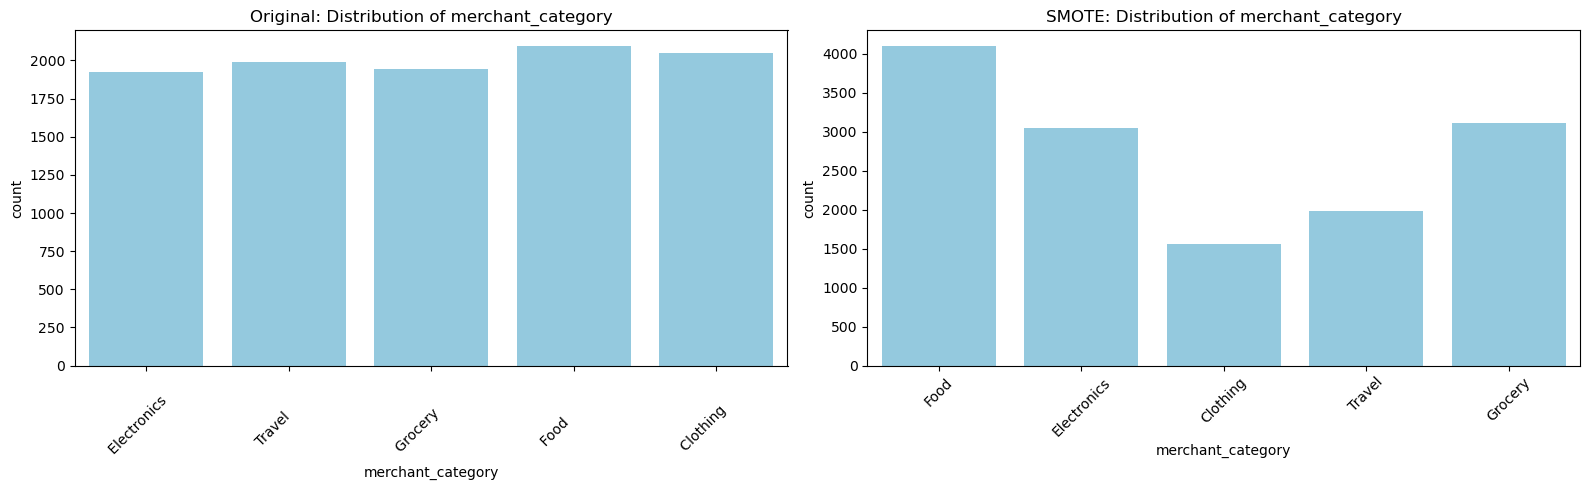

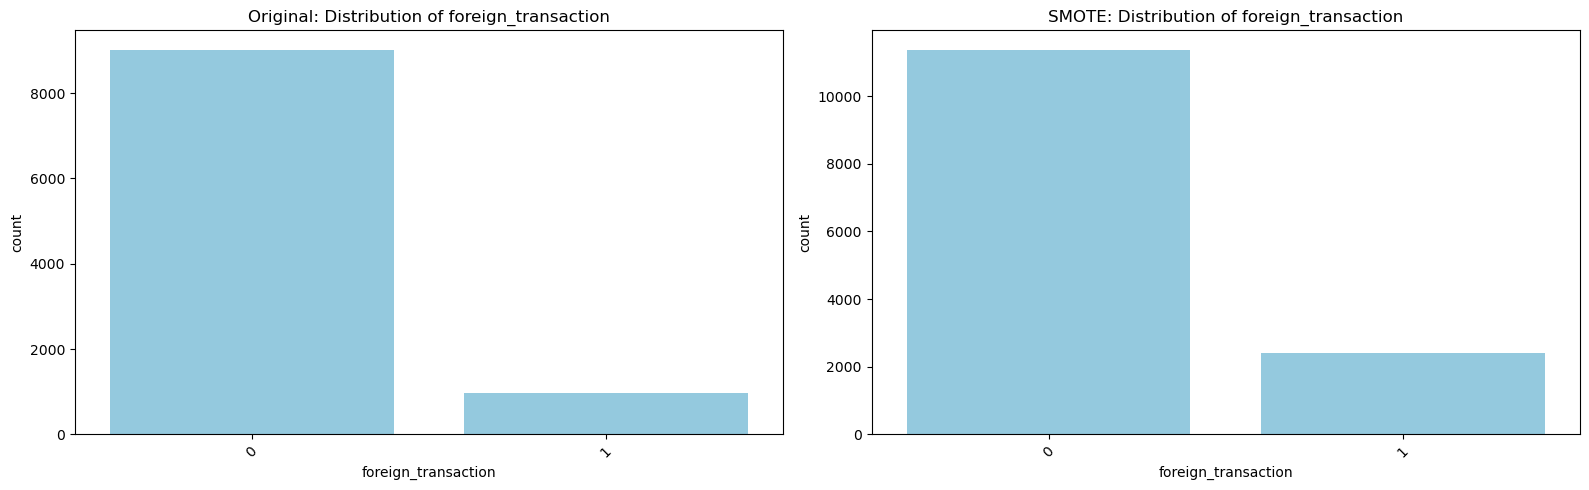

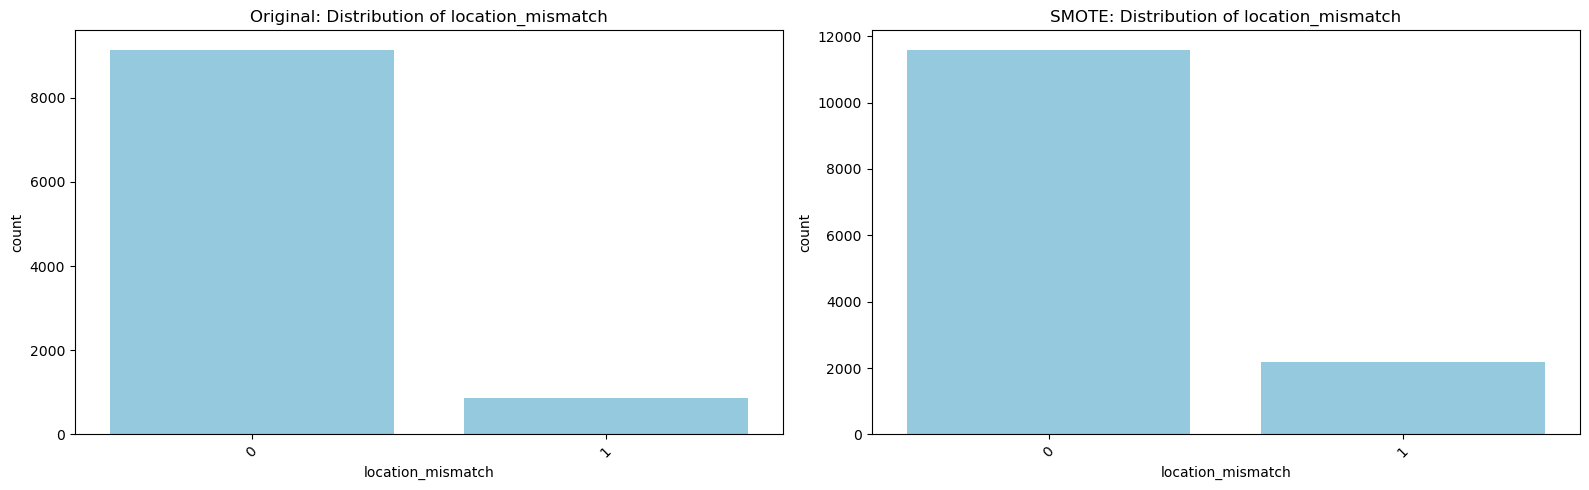


Pie Charts: Original vs SMOTE


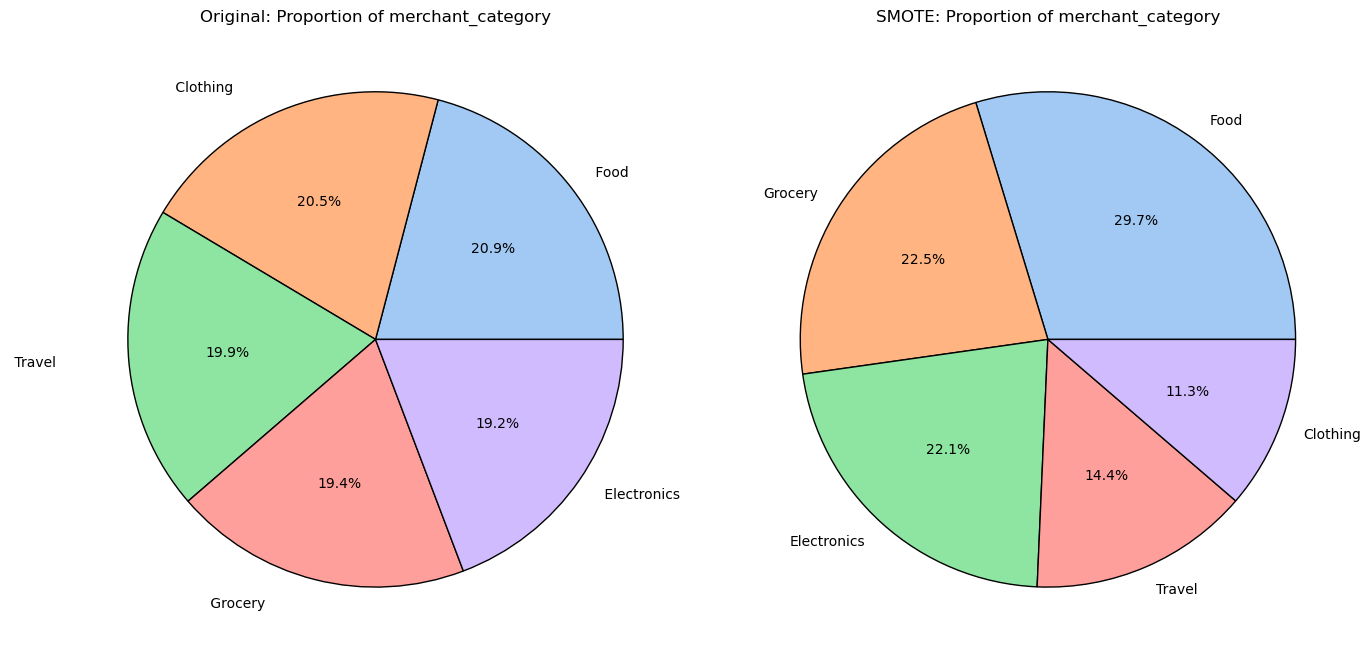

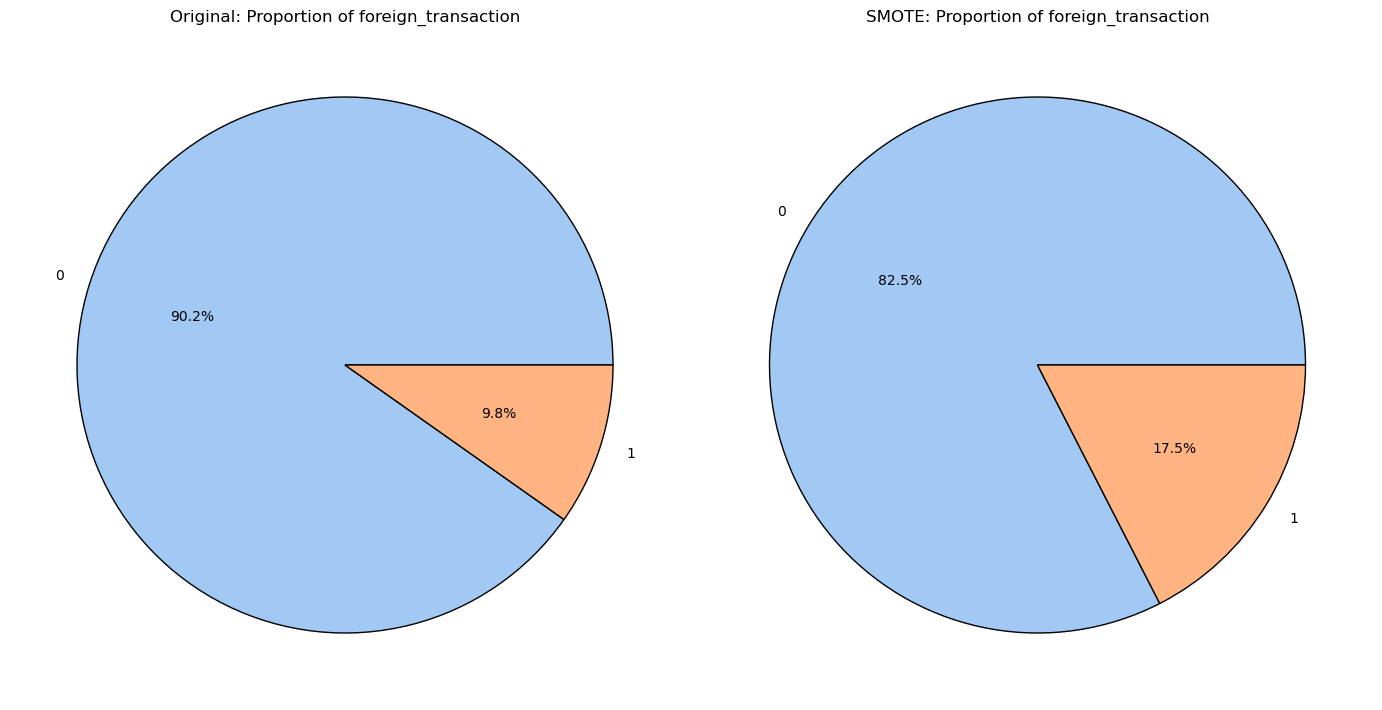

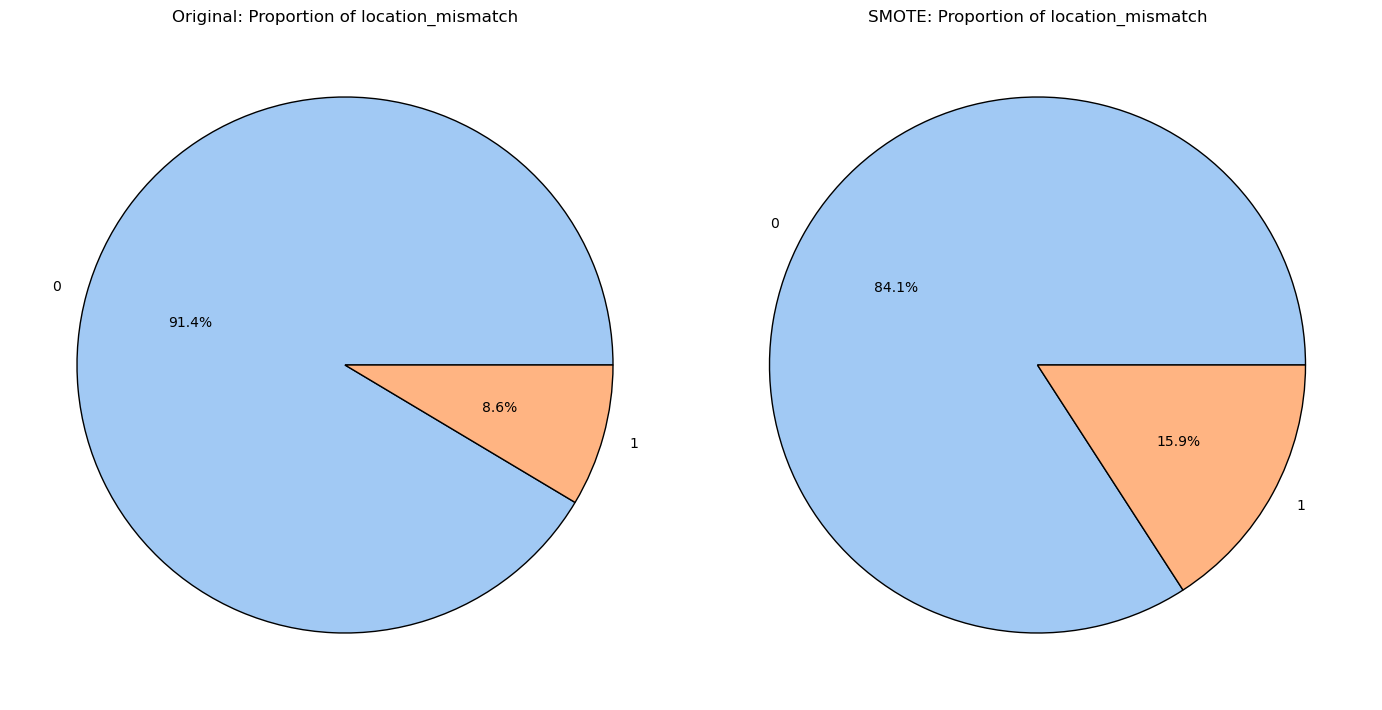


Target Variable Balance: Original vs SMOTE


C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\942356814.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=credit_data_df, palette=['lightblue', 'salmon'], ax=axes[0])
C:\Users\ben10\AppData\Local\Temp\ipykernel_28352\942356814.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=smote_data_df, palette=['lightblue', 'salmon'], ax=axes[1])


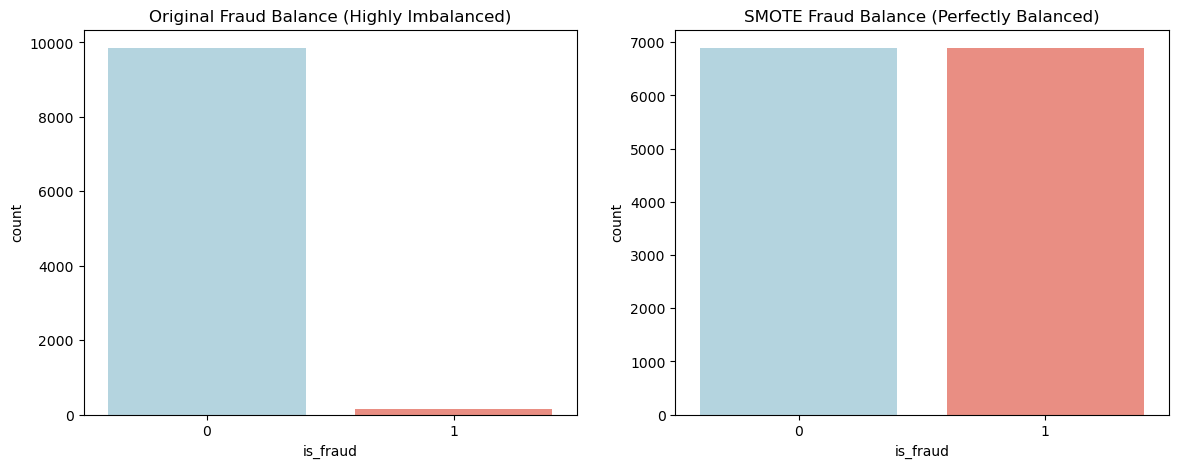

In [6]:
print("\nBar Charts: Original vs SMOTE")
for col in categorical_analysis_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.countplot(x=col, data=credit_data_df, color='skyblue', ax=axes[0])
    axes[0].set_title(f'Original: Distribution of {col}')
    axes[0].tick_params(axis='x', rotation=45)
    
    sns.countplot(x=col, data=smote_data_df, color='skyblue', ax=axes[1])
    axes[1].set_title(f'SMOTE: Distribution of {col}')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

print("\nPie Charts: Original vs SMOTE")
for col in categorical_analysis_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    counts_orig = credit_data_df[col].value_counts()
    axes[0].pie(
        counts_orig.values, 
        labels=counts_orig.index, 
        autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'),
        wedgeprops={'edgecolor': 'black'}
    )
    axes[0].set_title(f'Original: Proportion of {col}')
    
    counts_smote = smote_data_df[col].value_counts()
    axes[1].pie(
        counts_smote.values, 
        labels=counts_smote.index, 
        autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'),
        wedgeprops={'edgecolor': 'black'}
    )
    axes[1].set_title(f'SMOTE: Proportion of {col}')
    
    plt.tight_layout()
    plt.show()

print("\nTarget Variable Balance: Original vs SMOTE")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='is_fraud', data=credit_data_df, palette=['lightblue', 'salmon'], ax=axes[0])
axes[0].set_title('Original Fraud Balance (Highly Imbalanced)')

sns.countplot(x='is_fraud', data=smote_data_df, palette=['lightblue', 'salmon'], ax=axes[1])
axes[1].set_title('SMOTE Fraud Balance (Perfectly Balanced)')

plt.show()

### Bivariate Analysis - Numerical vs Numerical


BIVARIATE COMPARISON: AMOUNT vs TRANSACTION_HOUR


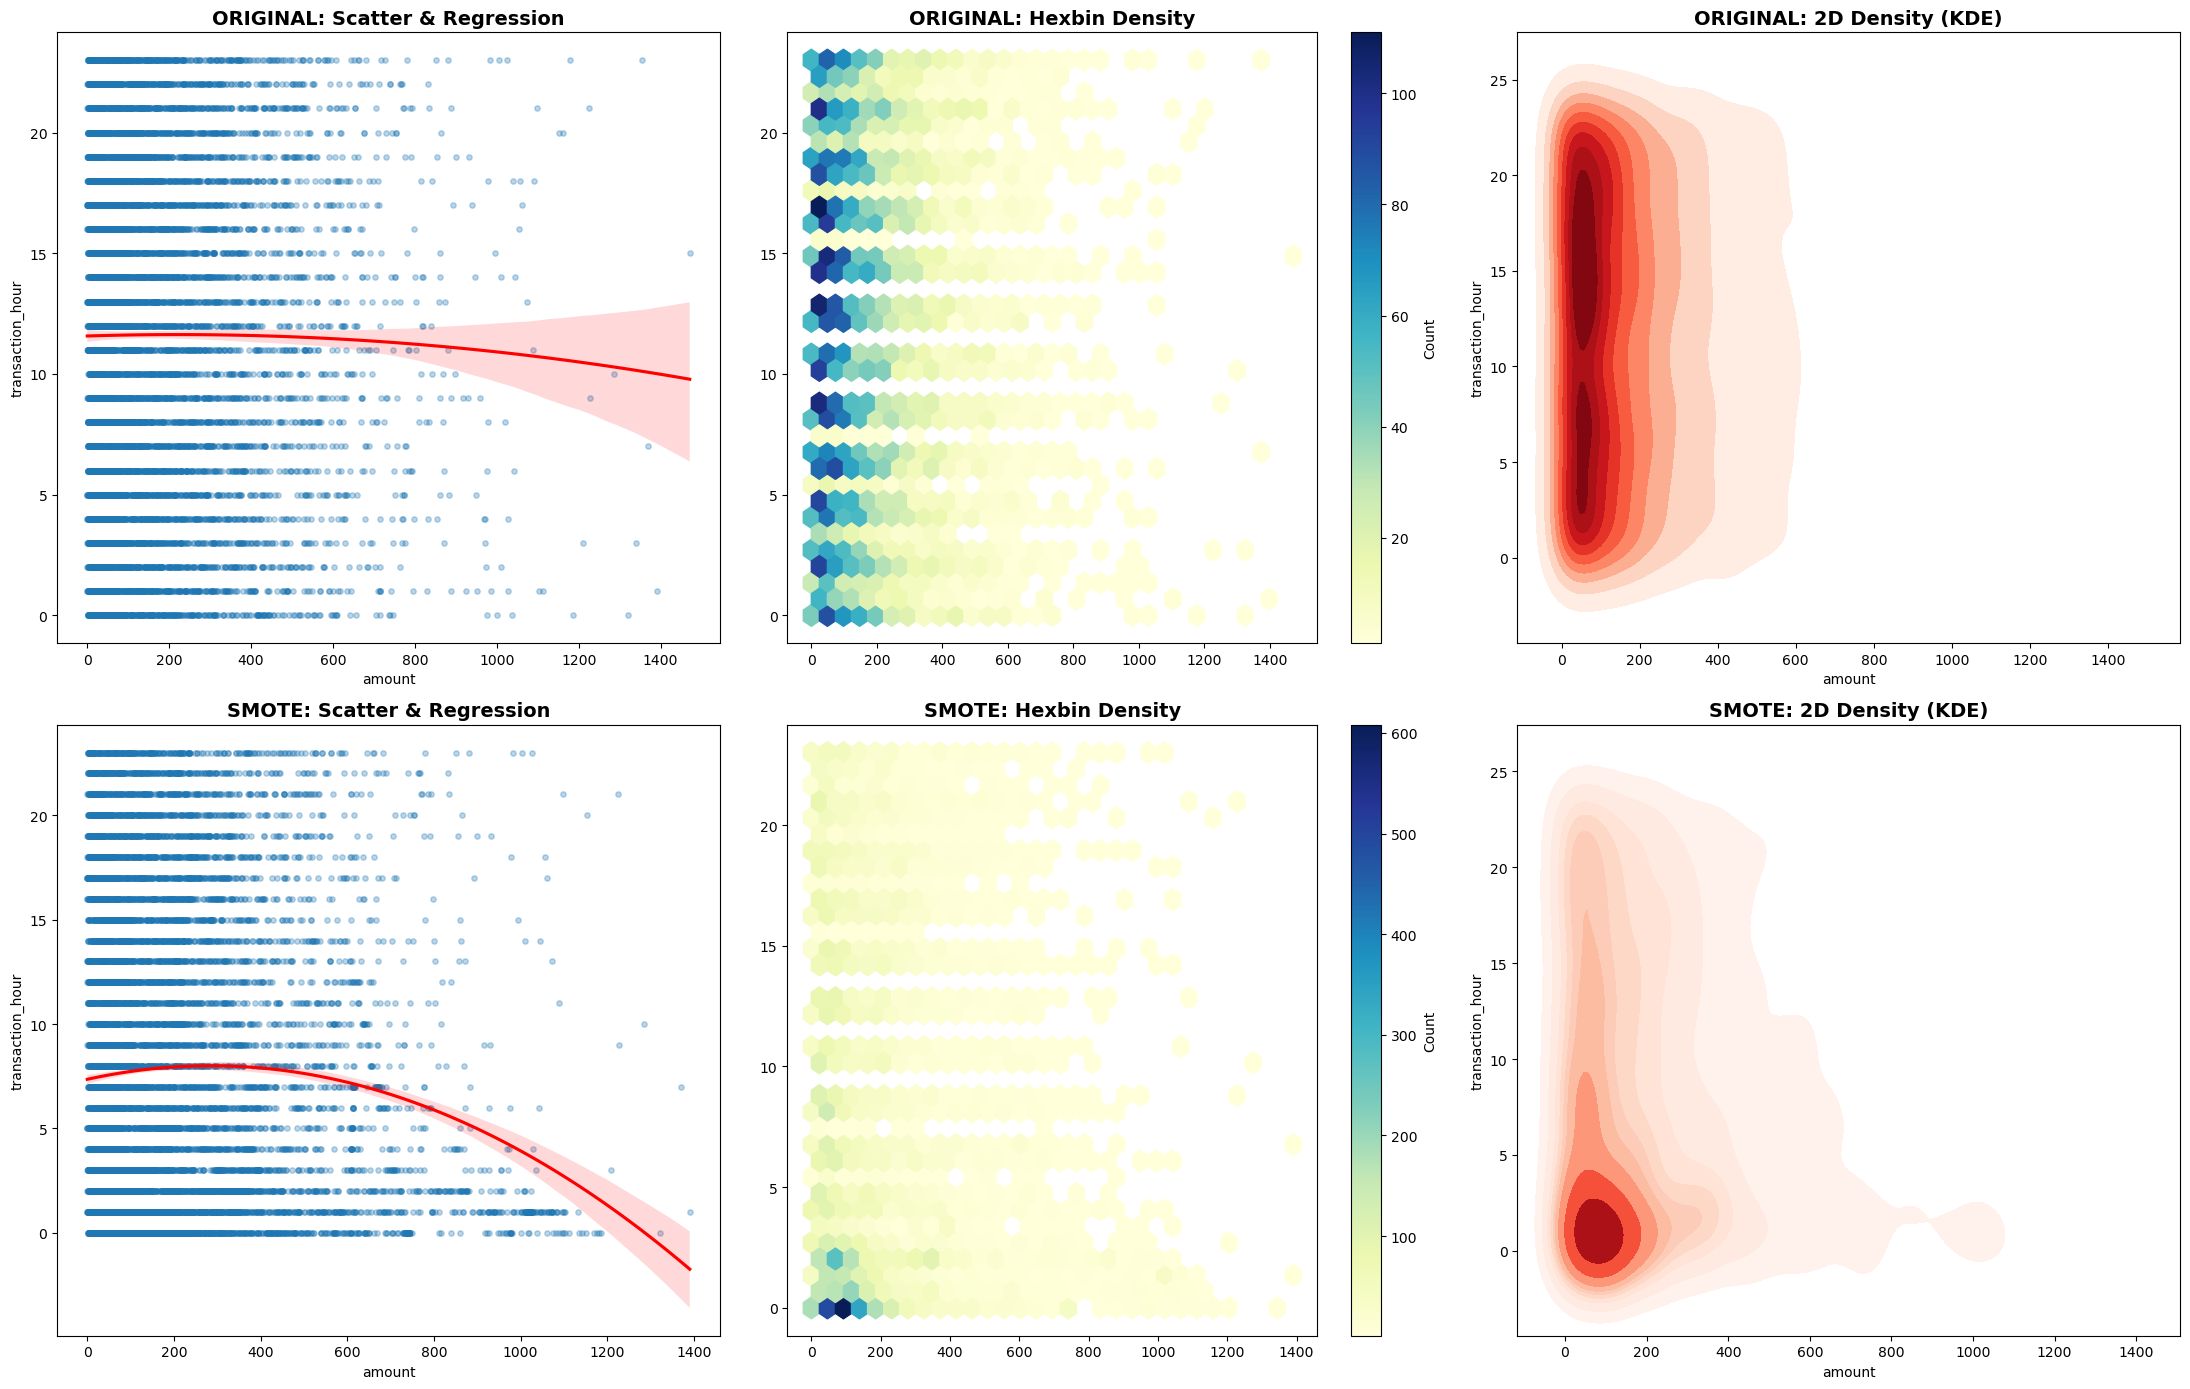


BIVARIATE COMPARISON: AMOUNT vs DEVICE_TRUST_SCORE


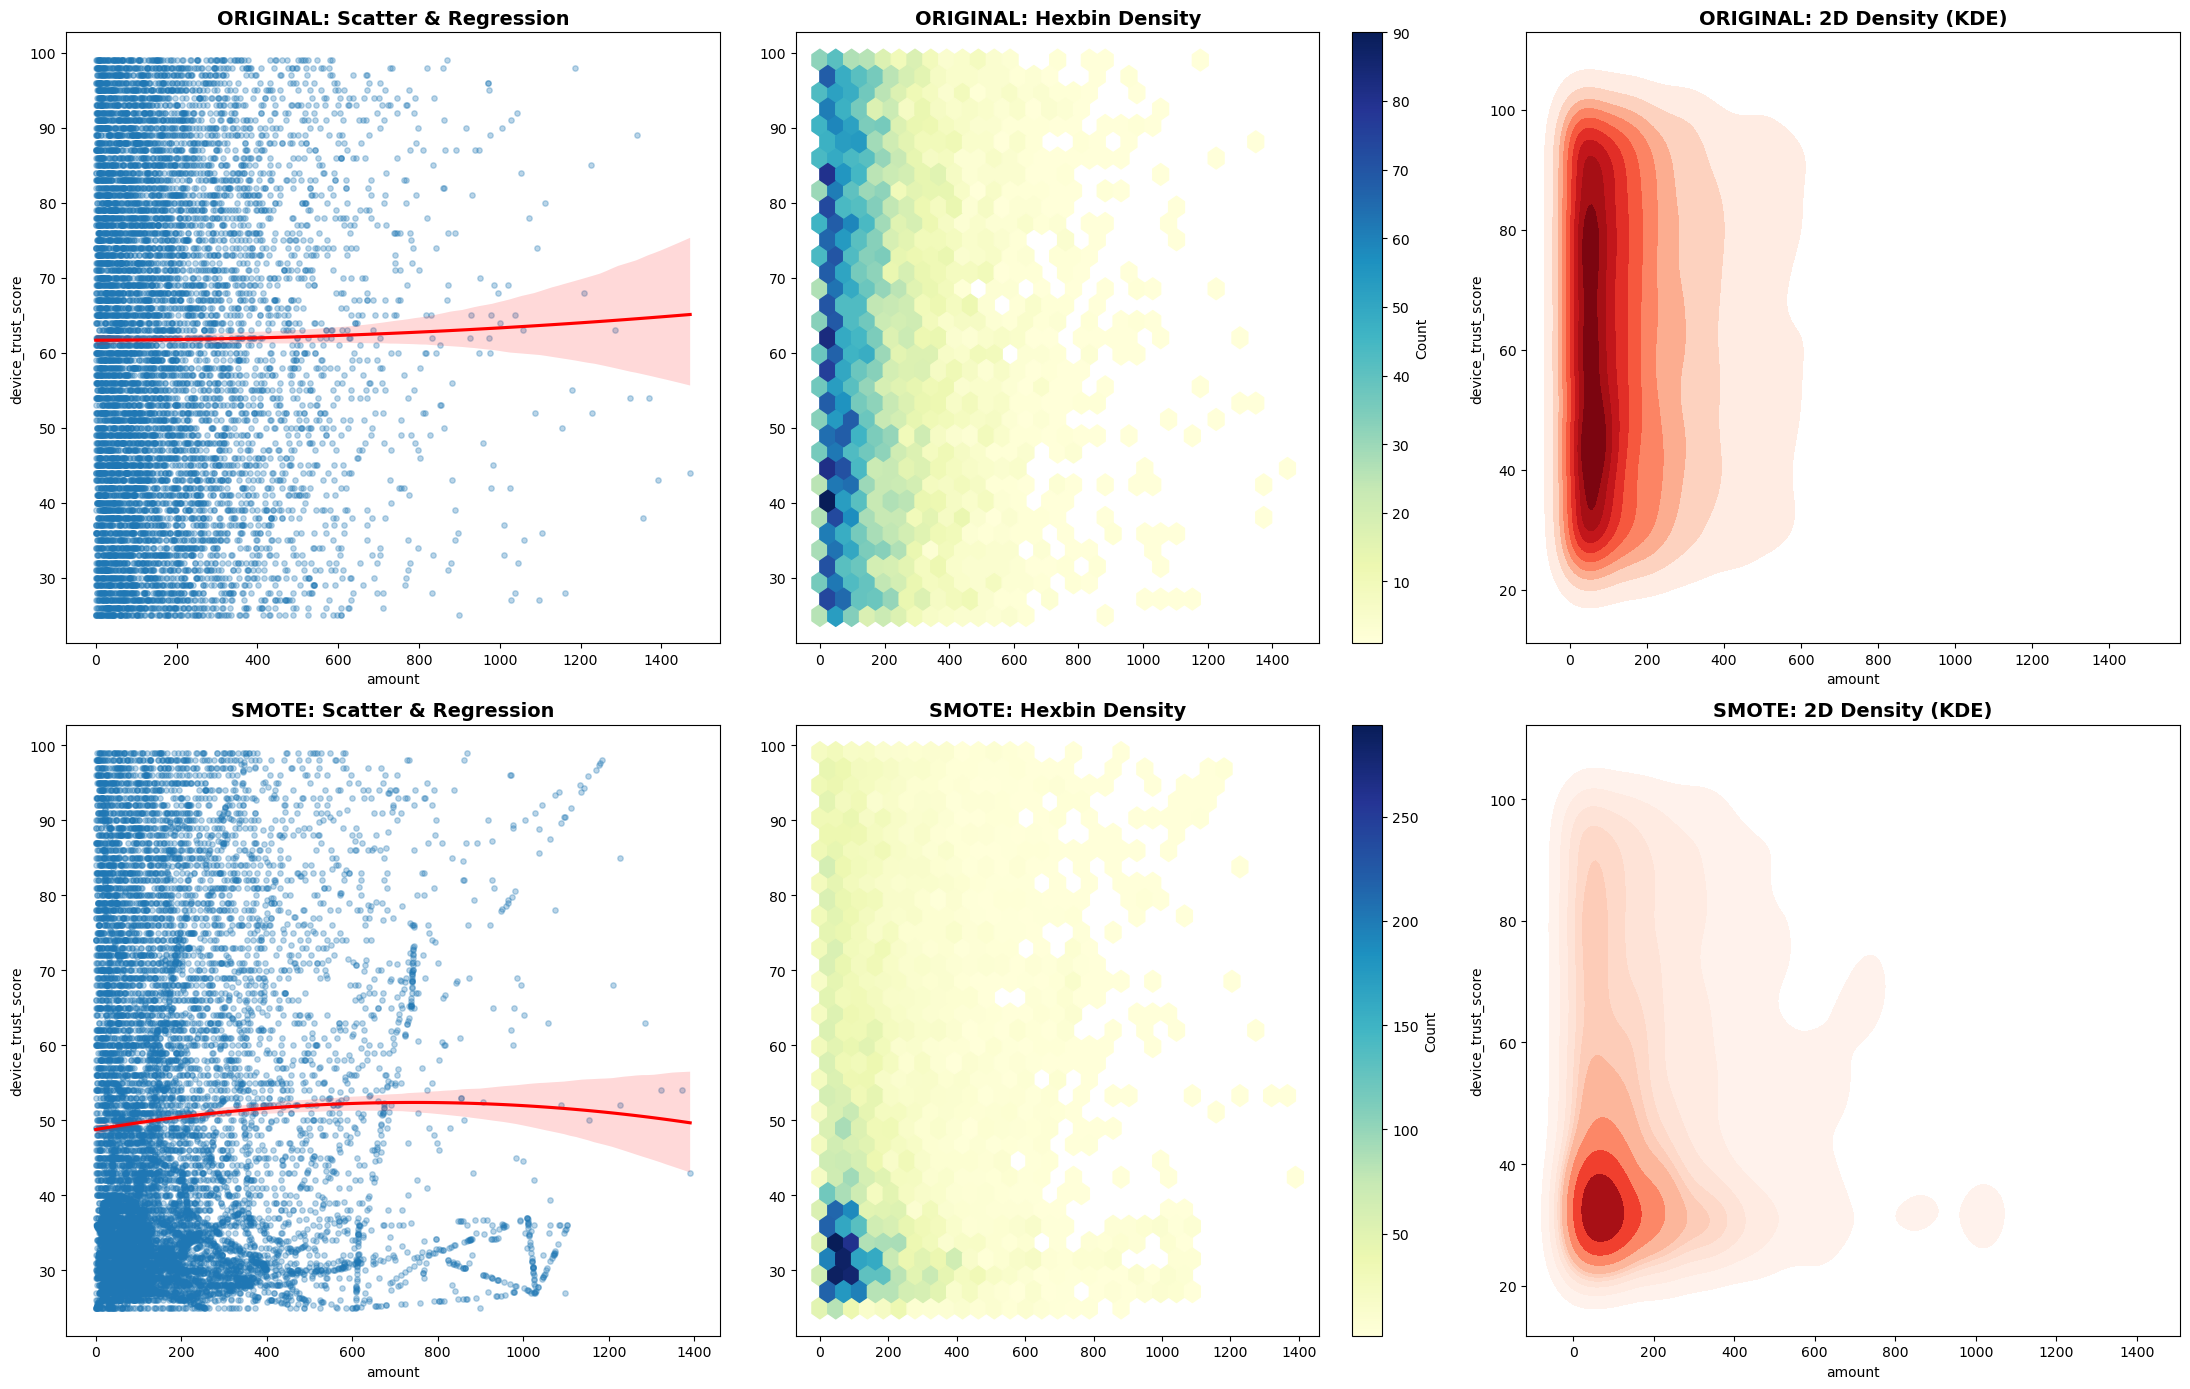


BIVARIATE COMPARISON: AMOUNT vs VELOCITY_LAST_24H


In [ ]:
pairs = list(itertools.combinations(continuous_cols, 2))

def plot_comparative_continuous_bivariate(df_orig, df_smote, column_pairs):
    for col1, col2 in column_pairs:
        print(f"\nBIVARIATE COMPARISON: {col1.upper()} vs {col2.upper()}")
        fig, axes = plt.subplots(2, 3, figsize=(22, 14))
        
        sns.regplot(x=col1, y=col2, data=df_orig, ax=axes[0, 0], 
                    scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'red'}, order=2)
        axes[0, 0].set_title(f'ORIGINAL: Scatter & Regression', fontsize=14, fontweight='bold')

        hb1 = axes[0, 1].hexbin(df_orig[col1], df_orig[col2], gridsize=30, cmap='YlGnBu', mincnt=1)
        fig.colorbar(hb1, ax=axes[0, 1], label='Count')
        axes[0, 1].set_title(f'ORIGINAL: Hexbin Density', fontsize=14, fontweight='bold')

        sns.kdeplot(data=df_orig, x=col1, y=col2, ax=axes[0, 2], cmap="Reds", fill=True, thresh=0.05)
        axes[0, 2].set_title(f'ORIGINAL: 2D Density (KDE)', fontsize=14, fontweight='bold')

        sns.regplot(x=col1, y=col2, data=df_smote, ax=axes[1, 0], 
                    scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'red'}, order=2)
        axes[1, 0].set_title(f'SMOTE: Scatter & Regression', fontsize=14, fontweight='bold')

        hb2 = axes[1, 1].hexbin(df_smote[col1], df_smote[col2], gridsize=30, cmap='YlGnBu', mincnt=1)
        fig.colorbar(hb2, ax=axes[1, 1], label='Count')
        axes[1, 1].set_title(f'SMOTE: Hexbin Density', fontsize=14, fontweight='bold')

        sns.kdeplot(data=df_smote, x=col1, y=col2, ax=axes[1, 2], cmap="Reds", fill=True, thresh=0.05)
        axes[1, 2].set_title(f'SMOTE: 2D Density (KDE)', fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.show()

plot_comparative_continuous_bivariate(credit_data_df, smote_data_df, pairs)

### Bivariate Analysis – Numerical vs Target

In [ ]:
def plot_comparative_target_bivariate(df_orig, df_smote, features, target='is_fraud'):
    for col in features:
        print(f"\nTARGET BIVARIATE COMPARISON: {col.upper()} vs {target.upper()}")
        fig, axes = plt.subplots(2, 3, figsize=(22, 12))
       
        sns.boxplot(x=target, y=col, data=df_orig, ax=axes[0, 0], palette=fraud_colors)
        axes[0, 0].set_title(f'ORIGINAL: Box Plot {col}', fontsize=12, fontweight='bold')
        
        df_sample_orig = df_orig.sample(min(1000, len(df_orig)), random_state=42)
        sns.stripplot(x=target, y=col, data=df_sample_orig, color='gray', alpha=0.3, ax=axes[0, 1])
        sns.swarmplot(x=target, y=col, data=df_sample_orig, hue=target, palette=fraud_colors, size=3, ax=axes[0, 1], legend=False)
        axes[0, 1].set_title(f'ORIGINAL: Strip/Swarm {col} (Sampled)', fontsize=12, fontweight='bold')
        
        sns.histplot(data=df_orig, x=col, hue=target, element="step", palette=fraud_colors, bins=30, ax=axes[0, 2], common_norm=False)
        axes[0, 2].set_title(f'ORIGINAL: Histogram/KDE {col}', fontsize=12, fontweight='bold')

        sns.boxplot(x=target, y=col, data=df_smote, ax=axes[1, 0], palette=fraud_colors)
        axes[1, 0].set_title(f'SMOTE: Box Plot {col}', fontsize=12, fontweight='bold')
        
        df_sample_smote = df_smote.sample(min(1000, len(df_smote)), random_state=42)
        sns.stripplot(x=target, y=col, data=df_sample_smote, color='gray', alpha=0.3, ax=axes[1, 1])
        sns.swarmplot(x=target, y=col, data=df_sample_smote, hue=target, palette=fraud_colors, size=3, ax=axes[1, 1], legend=False)
        axes[1, 1].set_title(f'SMOTE: Strip/Swarm {col} (Sampled)', fontsize=12, fontweight='bold')
    
        sns.histplot(data=df_smote, x=col, hue=target, element="step", palette=fraud_colors, bins=30, ax=axes[1, 2], common_norm=False)
        axes[1, 2].set_title(f'SMOTE: Histogram/KDE {col}', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.show()

plot_comparative_target_bivariate(credit_data_df, smote_data_df, continuous_cols)

### Bivariate Analysis – Categorical vs Target

In [ ]:
def perform_comparative_categorical_analysis(df_orig, df_smote, cat_cols):
    cols_to_pair = cat_cols + ['is_fraud'] if 'is_fraud' not in cat_cols else cat_cols
    feature_pairs = list(itertools.combinations(cols_to_pair, 2))
    
    for primary_feature, secondary_feature in feature_pairs:
        print(f"CATEGORICAL COMPARISON: {primary_feature.upper()} vs {secondary_feature.upper()}")
        datasets = [('ORIGINAL', df_orig), ('SMOTE', df_smote)]

        print("\nCLUSTERED BAR CHARTS:")
        fig, axes = plt.subplots(1, 2, figsize=(20, 6))
        for ax, (label, df) in zip(axes, datasets):
            current_palette = fraud_colors if secondary_feature == 'is_fraud' else 'viridis'
            sns.countplot(data=df, x=primary_feature, hue=secondary_feature, palette=current_palette, ax=ax)
            ax.set_title(f'{label}: Clustered Bar - {primary_feature} by {secondary_feature}', fontsize=12, fontweight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.legend(title=secondary_feature)
        plt.tight_layout()
        plt.show()

        print("\nSTACKED BAR CHARTS:")
        fig, axes = plt.subplots(1, 2, figsize=(20, 6))
        for ax, (label, df) in zip(axes, datasets):
            contingency_matrix = pd.crosstab(df[primary_feature], df[secondary_feature]).fillna(0)
            current_colors = fraud_colors if secondary_feature == 'is_fraud' else None
            contingency_matrix.plot(kind='bar', stacked=True, ax=ax, color=current_colors, edgecolor='black')
            ax.set_title(f'{label}: Stacked Bar - {primary_feature} by {secondary_feature}', fontsize=12, fontweight='bold')
            ax.set_ylabel('Count')
            ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

        print("\nHEATMAP COMPARISON:")
        fig, axes = plt.subplots(1, 2, figsize=(20, 7))
        for ax, (label, df) in zip(axes, datasets):
            con_table = pd.crosstab(df[primary_feature], df[secondary_feature]).fillna(0)
            sns.heatmap(con_table, annot=True, fmt='g', cmap='magma', cbar_kws={'label': 'Count'}, ax=ax)
            ax.set_title(f'{label}: Heatmap - {primary_feature} vs {secondary_feature}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

        for label, df in datasets:
            print(f"\n{label} PIE CHARTS")
            unique_categories = [cat for cat in df[primary_feature].unique() if pd.notna(cat)]
            num_plots = len(unique_categories)
            num_cols = 3
            num_rows = (num_plots + num_cols - 1) // num_cols

            fig, axes_grid = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 5))
            fig.suptitle(f'{label}: Pie Charts - {secondary_feature} in {primary_feature}', fontsize=16, fontweight='bold', y=1.02)

            axes_flat = axes_grid.flatten() if num_plots > 1 else [axes_grid]

            for idx, category_label in enumerate(unique_categories):
                subset = df[df[primary_feature] == category_label][secondary_feature].value_counts().sort_index()

                if not subset.empty:
                    if secondary_feature == 'is_fraud':
                        pie_colors = [fraud_colors[int(val)] for val in subset.index]
                    else:
                        pie_colors = sns.color_palette('pastel')

                    axes_flat[idx].pie(subset, labels=subset.index, autopct='%1.1f%%', colors=pie_colors, wedgeprops={'edgecolor':'black'})
                    axes_flat[idx].set_title(f'{category_label}', fontsize=11)
                else:
                    axes_flat[idx].axis('off')

            for empty_idx in range(idx + 1, len(axes_flat)):
                axes_flat[empty_idx].axis('off')

            plt.tight_layout(rect=[0, 0, 1, 0.98])
            plt.show()

        print("\nCLUSTER MAPS:")
        for label, df in datasets:
            con_matrix = pd.crosstab(df[primary_feature], df[secondary_feature]).fillna(0)
            try:
                cluster_vis = sns.clustermap(con_matrix, annot=True, fmt='g', cmap='mako', standard_scale=1, figsize=(8, 6))
                cluster_vis.fig.suptitle(f'{label}: Cluster Map - {primary_feature} & {secondary_feature}', y=1.05, fontsize=14, fontweight='bold')
                plt.show()
            except Exception as e:
                print(f"Could not generate Cluster Map for {label}: {e}")


perform_comparative_categorical_analysis(credit_data_df, smote_data_df, categorical_analysis_cols)

### Multivariate Analysis

In [ ]:
print("\nCORRELATION MATRIX COMPARISON\n")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

datasets = [('ORIGINAL', credit_data_df), ('SMOTE', smote_data_df)]

for ax, (label, df) in zip(axes, datasets):
    corr = df[continuous_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.4f', cmap='coolwarm', 
                vmin=-0.1, vmax=0.1, center=0, ax=ax,
                cbar_kws={'label': 'Correlation Coefficient'})
    ax.set_title(f'{label}: Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n2. PAIR PLOT COMPARISON\n")
for label, df in datasets:
    print(f"Generating Pair Plot for {label} data...")
    # Sampling for performance
    sample_df = df[continuous_cols + ['is_fraud']].sample(min(2000, len(df)))
    g = sns.pairplot(sample_df, hue='is_fraud', palette=fraud_colors, diag_kind='hist', height=2.5)
    g.fig.suptitle(f'{label}: Pair Plots Colored by Fraud Status', y=1.02, fontsize=16, fontweight='bold')
    plt.show()

print("\nPARALLEL COORDINATES COMPARISON\n")
fig, axes = plt.subplots(2, 1, figsize=(18, 14))

for i, (label, df) in enumerate(datasets):
    # Min-Max Normalization for visual clarity
    df_norm = df.copy()
    for feature in continuous_cols:
        df_norm[feature] = (df_norm[feature] - df_norm[feature].min()) / \
                           (df_norm[feature].max() - df_norm[feature].min())
    
    parallel_coordinates(df_norm[continuous_cols + ['is_fraud']], 
                         class_column='is_fraud', color=fraud_colors, alpha=0.1, ax=axes[i])
    axes[i].set_title(f'{label}: Normalized Parallel Coordinates', fontsize=14, fontweight='bold')
    axes[i].legend(title='Is Fraud', labels=['Legit (0)', 'Fraud (1)'])
    axes[i].grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

print("\n3D SCATTER PLOT COMPARISON\n")
three_way_combinations = list(itertools.combinations(continuous_cols, 3))

for x_feat, y_feat, z_feat in three_way_combinations:
    fig = plt.figure(figsize=(22, 10))
    
    ax1 = fig.add_subplot(121, projection='3d')
    plot_orig = credit_data_df.sample(min(3000, len(credit_data_df)))
    ax1.scatter(plot_orig[x_feat], plot_orig[y_feat], plot_orig[z_feat], 
                c=plot_orig['is_fraud'].map({0: 'lightblue', 1: 'salmon'}), 
                alpha=0.5, edgecolors='w', s=30)
    ax1.set_title(f'ORIGINAL: {x_feat}/{y_feat}/{z_feat}')
    ax1.set_xlabel(x_feat); ax1.set_ylabel(y_feat); ax1.set_zlabel(z_feat)
    
    ax2 = fig.add_subplot(122, projection='3d')
    plot_smote = smote_data_df.sample(min(3000, len(smote_data_df)))
    ax2.scatter(plot_smote[x_feat], plot_smote[y_feat], plot_smote[z_feat], 
                c=plot_smote['is_fraud'].map({0: 'lightblue', 1: 'salmon'}), 
                alpha=0.5, edgecolors='w', s=30)
    ax2.set_title(f'SMOTE: {x_feat}/{y_feat}/{z_feat}')
    ax2.set_xlabel(x_feat); ax2.set_ylabel(y_feat); ax2.set_zlabel(z_feat)
    
    plt.show()


print("\nBUBBLE CHART COMPARISON\n")
for x_feat, y_feat, size_feat in three_way_combinations:
    fig, axes = plt.subplots(2, 1, figsize=(15, 16))
    
    for i, (label, df) in enumerate(datasets):
        sns.scatterplot(x=x_feat, y=y_feat, size=size_feat, hue='is_fraud', 
                        data=df.sample(min(2000, len(df))), 
                        palette=fraud_colors, alpha=0.5, sizes=(20, 300), ax=axes[i])
        axes[i].set_title(f'{label}: Bubble Chart ({x_feat} vs {y_feat}, Size={size_feat})', fontweight='bold')
        axes[i].legend(title='Is Fraud', bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

### Time Based Patterns

In [ ]:
def analyze_comparative_temporal_outliers(df_orig, df_smote, continuous_features, time_col='transaction_hour', target='is_fraud'):
    datasets = [('ORIGINAL', df_orig), ('SMOTE', df_smote)]

    for col in continuous_features:
        if col == time_col: continue
        
        print(f"TEMPORAL ANALYSIS: {col.upper()} vs {time_col.upper()}")
        
        fig, axes = plt.subplots(2, 2, figsize=(22, 14))
        
        for i, (label, df) in enumerate(datasets):
            seasonal_data = df.groupby([time_col, target])[col].mean().unstack()
            seasonal_data.plot(ax=axes[i, 0], marker='o', color=fraud_colors)
            axes[i, 0].set_title(f'{label}: Average {col} per Hour', fontsize=14, fontweight='bold')
            axes[i, 0].set_ylabel(f'Mean {col}')
            axes[i, 0].legend(title=target, labels=['Legit', 'Fraud'])
            axes[i, 0].grid(True, alpha=0.3)
            axes[i, 0].set_xticks(range(0, 24))

            sns.boxplot(data=df, x=time_col, y=col, hue=target, 
                        palette=fraud_colors, ax=axes[i, 1])
            axes[i, 1].set_title(f'{label}: {col} Distribution per Hour', fontsize=14, fontweight='bold')
            axes[i, 1].set_xticks(range(0, 24))
            
        plt.tight_layout()
        plt.show()

    print("\nGLOBAL FRAUD RATE vs VOLUME\n")
    fig, axes = plt.subplots(2, 1, figsize=(18, 14))

    for i, (label, df) in enumerate(datasets):
        ax1 = axes[i]
        
        hourly_fraud = df.groupby(time_col)[target].mean()
        sns.lineplot(x=hourly_fraud.index, y=hourly_fraud.values, marker='o', color='salmon', ax=ax1, label='Fraud Rate')
        ax1.set_ylabel('Fraud Rate', color='salmon', fontsize=12, fontweight='bold')
        ax1.tick_params(axis='y', labelcolor='salmon')

        ax2 = ax1.twinx()
        hourly_volume = df.groupby(time_col).size()
        sns.lineplot(x=hourly_volume.index, y=hourly_volume.values, marker='s', color='lightblue', ax=ax2, label='Volume')
        ax2.set_ylabel('Transaction Volume', color='lightblue', fontsize=12, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor='lightblue')

        ax1.set_title(f'{label}: Fraud Seasonality vs. Transaction Volume', fontsize=15, fontweight='bold')
        ax1.set_xticks(range(0, 24))
        ax1.grid(True, alpha=0.2)
        
    plt.tight_layout()
    plt.show()


analyze_comparative_temporal_outliers(credit_data_df, smote_data_df, continuous_cols)

### Amount Analysis Deep Dive

In [ ]:
def plot_comparative_amount_quantiles(df_orig, df_smote, target='is_fraud'):
    print("\nFRAUD RATE BY AMOUNT QUANTILES: ORIGINAL vs SMOTE\n")
    
    datasets = [('ORIGINAL', df_orig), ('SMOTE', df_smote)]
    fig, axes = plt.subplots(2, 1, figsize=(15, 14))

    for i, (label, df) in enumerate(datasets):
        temp_df = df.copy()
        temp_df['amount_bin'] = pd.qcut(temp_df['amount'], q=10, duplicates='drop')
        
        amount_fraud_rate = temp_df.groupby('amount_bin')[target].mean()
        
        sns.barplot(
            x=amount_fraud_rate.index.astype(str), 
            y=amount_fraud_rate.values, 
            color='salmon' if label == 'SMOTE' else 'coral',
            ax=axes[i]
        )
        
        axes[i].set_title(f'{label}: Fraud Rate by Amount Quantiles', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Amount Quantiles (Bins)')
        axes[i].set_ylabel('Mean Fraud Rate')
        axes[i].tick_params(axis='x', rotation=45)
        
        global_mean = df[target].mean()
        axes[i].axhline(global_mean, ls='--', color='black', alpha=0.6, label=f'Global Mean ({global_mean:.2f})')
        axes[i].legend()

    plt.tight_layout()
    plt.show()


plot_comparative_amount_quantiles(credit_data_df, smote_data_df)

### Velocity and Behavior Signals


In [ ]:
print("\nVELOCITY LAST 24H: ORIGINAL vs SMOTE\n")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.boxplot(
    x='is_fraud', 
    y='velocity_last_24h', 
    data=credit_data_df, 
    palette=fraud_colors,
    ax=axes[0]
)
axes[0].set_title('ORIGINAL: Velocity Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Is Fraud (0=No, 1=Yes)')
axes[0].set_ylabel('Velocity Last 24h')

sns.boxplot(
    x='is_fraud', 
    y='velocity_last_24h', 
    data=smote_data_df, 
    palette=fraud_colors,
    ax=axes[1]
)
axes[1].set_title('SMOTE: Velocity Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Is Fraud (0=No, 1=Yes)')
axes[1].set_ylabel('Velocity Last 24h')

plt.tight_layout()
plt.show()

### Device Trust and Location Signals

In [ ]:
datasets = [('ORIGINAL', credit_data_df), ('SMOTE', smote_data_df)]

print("\nDEVICE TRUST SCORE DISTRIBUTION: ORIGINAL vs SMOTE")

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for i, (label, df) in enumerate(datasets):
    sns.histplot(
        data=df, 
        x='device_trust_score', 
        hue='is_fraud', 
        bins=30, 
        kde=True,
        palette=fraud_colors, 
        edgecolor='black', 
        alpha=0.3,
        ax=axes[i]
    )
    axes[i].set_title(f'{label}: Device Trust Score Distribution', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Device Trust Score')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(title='Is Fraud', labels=['Fraud (1)', 'Legit (0)'])

plt.tight_layout()
plt.show()

### Demographic Insight (Age)

In [ ]:
datasets = [('ORIGINAL', credit_data_df), ('SMOTE', smote_data_df)]

print("\nDEMOGRAPHIC ANALYSIS: CARDHOLDER AGE (ORIGINAL vs SMOTE)\n")

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for i, (label, df) in enumerate(datasets):
    sns.histplot(
        data=df, 
        x='cardholder_age', 
        hue='is_fraud', 
        bins=30, 
        kde=True,
        palette=fraud_colors, 
        edgecolor='black', 
        alpha=0.3,
        ax=axes[i]
    )
    axes[i].set_title(f'{label}: Age Distribution by Fraud Status', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Cardholder Age')
    axes[i].set_ylabel('Frequency')
    
    axes[i].legend(title='Is Fraud', labels=['Fraud (1)', 'Legit (0)'])

plt.tight_layout()
plt.show()

### Interaction Exploration 

In [ ]:
def perform_comparative_interaction_exploration(df_orig, df_smote, continuous_features, categorical_features, target='is_fraud'):
    datasets = [('ORIGINAL', df_orig), ('SMOTE', df_smote)]

    print("\nCONTINUOUS vs CONTINUOUS INTERACTIONS\n")
    cont_pairs = list(itertools.combinations(continuous_features, 2))
    for x_feat, y_feat in cont_pairs:
        for label, df in datasets:
            g = sns.lmplot(
                x=x_feat, y=y_feat, hue=target, data=df,
                palette=fraud_colors, scatter_kws={'alpha':0.2, 's':15},
                height=6, aspect=1.5, line_kws={'lw': 3}
            )
            plt.title(f'{label}: Regression Interaction - {x_feat} vs {y_feat}', fontsize=14, fontweight='bold')
            plt.show()

    print("\nCATEGORICAL vs CATEGORICAL INTERACTIONS\n")
    cat_pairs = list(itertools.combinations(categorical_features, 2))
    for col1, col2 in cat_pairs:
        fig, axes = plt.subplots(1, 2, figsize=(22, 7))
        for ax, (label, df) in zip(axes, datasets):
            sns.countplot(x=col1, hue=col2, data=df, palette='viridis', ax=ax)
            ax.set_title(f'{label}: {col1} vs {col2}', fontsize=12, fontweight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.legend(title=col2, bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()

    print("\nCONTINUOUS vs CATEGORICAL INTERACTIONS\n")
    for cont_feat in continuous_features:
        for cat_feat in categorical_features[:2]: 
            fig, axes = plt.subplots(2, 1, figsize=(18, 12))
            for i, (label, df) in enumerate(datasets):
                sns.boxplot(x=cat_feat, y=cont_feat, hue=target, data=df, palette=fraud_colors, ax=axes[i])
                axes[i].set_title(f'{label}: {cont_feat} across {cat_feat}', fontsize=13, fontweight='bold')
                axes[i].tick_params(axis='x', rotation=45)
            plt.tight_layout()
            plt.show()

    print("\nFACETED SPATIAL INTERACTION (HOUR vs AMOUNT)\n")
    if 'transaction_hour' in df_orig.columns and 'amount' in df_orig.columns:
        for label, df in datasets:
            g = sns.FacetGrid(df, col=target, hue=target, palette=fraud_colors, height=5, aspect=1.5)
            g.map(sns.scatterplot, "transaction_hour", "amount", alpha=0.3, s=25)
            g.add_legend()
            plt.subplots_adjust(top=0.85)
            g.fig.suptitle(f'{label}: Spatial Interaction Density - Hour vs Amount', fontsize=16, fontweight='bold')
            plt.show()

    print("\nFRAUD RISK HOTSPOTS (FRAUD RATE HEATMAPS)\n")
    for col1, col2 in cat_pairs:
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        for ax, (label, df) in zip(axes, datasets):
            risk_pivot = df.groupby([col1, col2])[target].mean().unstack().fillna(0)
            sns.heatmap(risk_pivot, annot=True, cmap='Reds', fmt='.2f', cbar_kws={'label': 'Fraud Rate'}, ax=ax)
            ax.set_title(f'{label}: Risk Hotspot - {col1} x {col2}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

perform_comparative_interaction_exploration(
    df_orig=credit_data_df, 
    df_smote=smote_data_df, 
    continuous_features=continuous_cols, 
    categorical_features=categorical_analysis_cols
)

## EDA Summary & Hypotheses
---
### **Key Findings**

- **Target Imbalance:** The dataset is highly imbalanced, with legitimate transactions significantly outnumbering fraud, as seen in the "blue soup" effect across all scatter, parallel coordinates and other plots.

- **Non-Linearity:** Individual numerical features show near-zero linear correlation with each other and with the fraud status, suggesting that simple linear models may struggle.

- **Temporal Burst Pattern:** Fraudulent transactions exhibit a "burst" behavior where velocity increases significantly during late-night hours, a trend not present in legitimate spending.

- **Geographic Risk:** A massive discrepancy exists in fraud rates based on location; over 50% of fraudulent transactions are foreign, compared to only ~10% of legitimate ones.

- **Device Trust Divergence:** Fraudulent transactions show a positive correlation between transaction amount and device trust, suggesting high-value fraud often involves sophisticated account or device hijacking.

---
### **Most Predictive Features (Potential "Signals")**

1. `foreign_transaction`: Shows the largest vertical separation between classes in regression analysis.

2. `velocity_last_24h`: Especially when interacting with transaction_hour.

3. `device_trust_score`: Particularly significant when analyzed alongside amount.

4. `location_mismatch`: High frequency of occurrence in fraud cases compared to the baseline.

---
### **Preprocessing & Data Issues to Fix**

- **Feature Scaling:** Parallel coordinates plots showed that amount (0–1500) dominates smaller-scale features like velocity (0–10). Min-Max scaling or Standardization is required.

- **Class Imbalance:** To prevent the model from simply "guessing" Legit every time, we must implement oversampling (SMOTE) or undersampling strategies.

- **Log Transformation:** The amount feature is heavily right-skewed; a log transformation is necessary to normalize the distribution for the model.

---
### **Proposed Feature Engineering**

1. **Temporal & Behavioral Indicators**
    - `is_night_transaction`: This will be a boolean flag for transactions occurring between 12 AM and 5 AM. Our regression analysis of `transaction_hour` vs `velocity_last_24h` showed a specific "burst" pattern at night.

    - `velocity_per_hour`: Since velocity is currently a 24-hour total, creating a ratio of `velocity_last_24h` / (`transaction_hour` + 1) might help identify sudden spikes in activity relative to the time of day.

    - `is_high_velocity_low_trust`: The bubble chart showed a cluster of fraud at high velocity and low trust. So we need to create a boolean flag: (`velocity_last_24h` > threshold) & (`device_trust_score` < threshold). Threshold needs to be a prenctile in order to avoid being too rigid in case velocity changed later so that it becomes self adjusting.

2. **Transactional & Geographic Complexity**
    - `high_risk_abroad`: The regression of `amount` vs `foreign_transaction` showed that fraud is significantly higher in foreign markets regardless of price. A combined flag `foreign_transaction` * `location_mismatch` would highlight the "Double-Mismatch" scenario.

    - `relative_amount`: Since the parallel coordinates plot showed `amount` is on a much larger scale than other features, creating a feature like `amount` / `average_merchant_category_amount` can show if a purchase is "out of character" for that specific category. 
    where `average_merchant_category_amount` is calculated as the **mean transaction amount for each specific merchant category** across the entire training dataset. This acts as a "behavioral baseline" allowing the model to detect when a transaction deviates significantly from the norm for that specific type of business.

3. **Mathematical Transformation**
    - `log_amount`: There is a need for a log transformation due to the skewed distribution of transaction `amount` values. This should be a permanent new column for the model.

    